#Spaceship Titanic

## Bienvenidos a la práctica de EDA.

En este notebook se nos presenta un "toy dataset" para poner en práctica lo que hemos aprendido hasta ahora sobre cómo realizar un buen EDA. Para la ejecución de la misma necesitaremos:
1. Un venv en local para que cada uno pueda trabajar de forma individual en las celdas que se os pida hacer algo.
2. Que abráis una cuenta en Kaggle (es gratuita). https://www.kaggle.com/  

Se nos presenta un ejercicio "Spaceship Titanic". Kaggle (www.kaggle.com) es una plataforma donde se reúnen miles de personas con interés o experiencia en
el análisis de datos, ofreciendo la posibilidad de competir para resolver requisitos estratégicos que presentan
los grandes datos de las empresas a cambio de dinero. Empresas y compa˜nías de todo el mundo exponen sus
problemas y sus retos en esta plataforma y la comunidad de científicos de datos compite para crear las mejores
soluciones y los mejores modelados teóricos.

En la plataforma se presenta cualquier tipo de problema que pueda encontrarse en los distintos campos del
mundo real, tales como servicios financieros, energía, tecnologías de la información, etc.
El enfoque crowdsourcing utilizado se debe a la existencia de una cantidad indefinida de posibles soluciones y
estrategias que se pueden aplicar a un problema complejo de modelado predictivo donde no es posible saber con
antelación la técnica o la estrategia que será más adecuada y más eficaz.
Fundada por el economista australiano Anthony Goldbloom, la inspiración para crear Kaggle proviene en parte
de una competición creada por Netflix entre 2006 y 2009. La empresa de alquiler de películas ofrecía un millón
de dólares al equipo que fuera capaz de mejorar la precisión de su sistema de recomendación de títulos en un
10 %.


## Objetivo

Este proyecto busca llevar a cabo un proyecto que permita demostrar las habilidades aprendidas durante el
curso. El primer requisito es que el conjunto de datos utilizado posea un número razonable de variables y
observaciones para que tengáis que ir más allá de la aplicación de un algoritmo simple de selección de variables
para la construcción de un modelo final. Y la mejor forma de aprender, es practicando.

En cuanto al problema a resolver, estamos en 2912 y se ha recibido una transmisión desde cuatro a˜nos luz
de distancia con malas noticias. La nave espacial Titanic emprendió un viaje interestelar para transportar
emigrantes de nuestro sistema solar a tres exoplanetas descubiertos recientemente que parecen habitables y
orbitan estrellas cercanas. Por desgracia, la nave espacial chocó con una anomalía escondida dentro de una nube
de polvo y casi la mitad de los pasajeros fueron transportados a una dimensión alternativa. El problema que se
presenta en esta competición es ayudar a las tripulaciones de rescate a recuperar a los pasajeros perdidos, para
lo cuál se debe predecir qué pasajeros fueron transportados por la anomalía utilizando los registros recuperados
del sistema informático da˜nado.

Con respecto al conjunto de datos, este está formado por 13000 instancias y 14 variables (incluyendo la variable
clase a predecir), las cuáles se centran en la descripción de multitud de aspectos de cada uno de los pasajeros.
En general, las variables categóricas hacen referencia al planeta de residencia, destino, etc. Por su parte, las
variables numéricas describen la edad, facturación por el servicio de habitaciones, compras, etc. Aquí tenéis en enlace a la competición: https://www.kaggle.com/competitions/spaceship-titanic

Vuestra tarea como aprendices en NTTData es predecir si los pasajeros fueron transportados a la dimensión alternativa o no. Para
comenzar a trabajar, se os facilitará una carpeta “Data” donde encontraremos los siguientes ficheros: train.csv, test.csv y
sample_submission.csv. El conjunto de datos de entrenamiento se encuentra en train.csv y consta de 8693
instancias. Por su parte, el conjunto de datos de prueba es test.csv, está formado por 4277 instancias y se
utilizará para realizar la predicción. Por último, el fichero sample_submission.csv proporciona un formato de
muestra para el envío de resultados a la plataforma Kaggle. 

Que la fuerza os acompañe!



In [1]:
# # Instalación de libs
# %pip install pandas
# %pip install numpy 
# %pip install matplotlib
# %pip install seaborn
# %pip install -U scikit-learn
# %pip install xgboost

In [2]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler, OrdinalEncoder, FunctionTransformer, KBinsDiscretizer, LabelEncoder
from sklearn.neural_network import MLPClassifier
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Lasso
from sklearn.feature_selection import SelectFromModel
from xgboost import XGBClassifier
from sklearn.model_selection import cross_validate
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score
from sklearn.model_selection import StratifiedKFold
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.feature_selection import RFE
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns



from sklearn import set_config
set_config(transform_output = "pandas")

EDA "EXPLORATORY DATA ANALYSIS"

Tres conjuntos distintos:

- Train (entrenamiento) → Para entrenar el modelo
- Validation (validación) → Para ajustar hiperparámetros y evaluar durante el desarrollo
- Test (test final) → Para medir el rendimiento final (no se toca hasta el final)

In [3]:
EDA_train_raw = pd.read_csv("data/train.csv", sep=",") #importamos csv todo el conjunto de train sin dividir

EDA_test_data=pd.read_csv("data/test.csv", sep=",") #importamos csv el conjunto de test para el test final

target_feature='Transported'

# train_test_split sirve para dividir el dataset en dos partes:
# - conjunto de entrenamiento (train): para entrenar el modelo
# - conjunto de validación/test (val): para evaluar el modelo en datos no vistos
# Esto ayuda a medir qué tal generaliza el modelo y evitar overfitting

X_train, X_val, y_train, y_val = train_test_split(
    # X: eliminamos la variable objetivo para quedarnos solo con las features
    EDA_train_raw.drop(columns=[target_feature]),  
    
    # y: seleccionamos la variable objetivo que queremos predecir
    EDA_train_raw[target_feature],

    # usamos el 30% de los datos para validación y el 70% para entrenamiento
    test_size=0.3,

    # mantenemos la misma proporción de clases (True/False) en train y validation
    # evita sesgos si el dataset está desbalanceado
    stratify=EDA_train_raw[target_feature]
)

#concatenamos los datos con el target en cada conjunto. Realmente el conjunto de val no lo voy a usar porque y sklearn aparta un % de los datos cuando hago la validacion cruzada anidada
X_train['Transported'] = y_train
X_val['Transported'] = y_val

In [4]:
print(X_train.shape)
print(y_train.shape)
print(X_val.shape)
print(y_val.shape)

(6085, 14)
(6085,)
(2608, 14)
(2608,)


In [5]:
X_train.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
7486,8010_01,Europa,False,C/300/S,TRAPPIST-1e,59.0,False,0.0,2593.0,0.0,98.0,0.0,NaN,True
5825,6168_01,Earth,True,G/999/S,PSO J318.5-22,16.0,False,0.0,0.0,0.0,0.0,0.0,Karie Gordond,True
5112,5465_02,NaN,False,F/1132/P,TRAPPIST-1e,49.0,False,226.0,11.0,2.0,1580.0,0.0,Cings Chité,False
5464,5825_01,Europa,False,B/198/P,TRAPPIST-1e,43.0,False,0.0,8808.0,0.0,580.0,0.0,Betenar Apenelexy,True
7937,8475_01,Europa,False,B/331/S,55 Cancri e,49.0,False,0.0,2808.0,1083.0,110.0,1132.0,Sadares Aindlylid,False


In [6]:
EDA_original_colnames=X_train.columns.tolist()

print('ALL', EDA_original_colnames)

EDA_original_numeric_columns = list(X_train.select_dtypes(include=['number']).columns)
print('NUM', EDA_original_numeric_columns)

EDA_original_cat_columns = list(X_train.select_dtypes(include=['object']).columns)
print('CAT', EDA_original_cat_columns)

ALL ['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Name', 'Transported']
NUM ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
CAT ['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'VIP', 'Name']


C:\Users\sgomezvi\AppData\Local\Temp\ipykernel_29092\215239909.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  EDA_original_cat_columns = list(X_train.select_dtypes(include=['object']).columns)


In [7]:
#listar el numero de valores NA por columna y sus porcentajes
X_train.isna().sum()

#en valor %
porcentaje_na_por_columna = X_train.isna().mean() * 100
print(porcentaje_na_por_columna)

PassengerId     0.000000
HomePlanet      2.251438
CryoSleep       2.382909
Cabin           2.087099
Destination     2.119967
Age             2.054232
VIP             2.317173
RoomService     1.889893
FoodCourt       1.906327
ShoppingMall    2.350041
Spa             1.906327
VRDeck          2.021364
Name            2.333607
Transported     0.000000
dtype: float64



#### IMPUTACIÓN DE VALORES NA

Imputar = rellenar valores faltantes (NaN) para poder usar el dataset en modelos (la mayoría de modelos no aceptan valores nulos)
#### 🔢 VARIABLES NUMÉRICAS
 -------------------------
 Aquí usamos la MEDIANA para rellenar los NA
 ¿Por qué mediana?
 - Es robusta a outliers (valores extremos)
 - Mejor que la media si la distribución está sesgada (muy común en datos reales)
 - Mantiene una representación más "realista" del centro de los datos

 Alternativas:
 - mean(): útil si los datos son normales (sin outliers)
 - 0 o constante: rápido pero puede distorsionar mucho
 - interpolación: útil en series temporales
 - modelos (KNN, regresión): más preciso pero más complejo


#### 🏷️ VARIABLES CATEGÓRICAS
 -------------------------
 Aquí usamos la MODA (valor más frecuente)
 ¿Por qué moda?
 - Tiene sentido porque son categorías (no puedes hacer media)
 - Mantiene la categoría más representativa

 Alternativas:
 - "Unknown" / "Missing": útil si el hecho de faltar es información relevante
 - imputación por grupo (ej: por PassengerId, grupo familiar, etc.)
 - modelos (ej: predecir categoría): más complejo

 ⚠️ IMPORTANTE:
 .mode() devuelve una serie → normalmente usamos el primer valor con [0]

In [8]:
#imputation NA values in numeric columns and categorical
EDA_train_raw_imputed = X_train.copy() 


EDA_train_raw_imputed[EDA_original_numeric_columns] = (
    X_train[EDA_original_numeric_columns]
    .fillna(X_train[EDA_original_numeric_columns].median())
)

EDA_train_raw_imputed[EDA_original_cat_columns] = (
    X_train[EDA_original_cat_columns]
    .fillna(X_train[EDA_original_cat_columns].mode().iloc[0])
)


EDA: Visualizaciones y plots

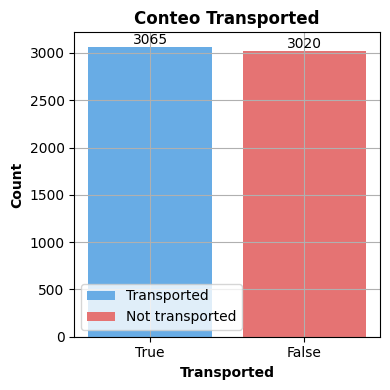

In [9]:
plt.figure(figsize = (4, 4))

counts = EDA_train_raw_imputed['Transported'].value_counts()

bars = plt.bar(['True', 'False'], EDA_train_raw_imputed['Transported'].value_counts(), color = ['#68ACE5', '#E57373'], label = ['Transported', 'Not transported'])

# Añadimos etiquetas con el valor encima de cada barra
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,  # posición X centrada
        height,                             # altura de la barra
        f'{int(height)}',                   # texto (valor)
        ha='center',                        # alineación horizontal
        va='bottom'                         # alineación vertical
    )

plt.title('Conteo Transported', fontweight = 'bold')
plt.xlabel('Transported', fontweight = 'bold')
plt.ylabel('Count', fontweight = 'bold')
plt.grid()
plt.legend()
plt.tight_layout()
plt.savefig('distribucion clase.png')
plt.show()
plt.close()

C:\Users\sgomezvi\AppData\Local\Temp\ipykernel_29092\398586710.py:6: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(ax=axes[0,0], data=EDA_train_raw_imputed, x='HomePlanet', multiple="stack", bins=10, palette='colorblind')
C:\Users\sgomezvi\AppData\Local\Temp\ipykernel_29092\398586710.py:10: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(ax=axes[0,1], data=EDA_train_raw_imputed, x='Destination', multiple="stack", bins=10, palette='colorblind')
C:\Users\sgomezvi\AppData\Local\Temp\ipykernel_29092\398586710.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[1,0], data=EDA_train_raw_imputed, x='VIP', palette='colorblind')
C:\Users\sgomezvi\AppData\Local\Temp\ipykernel_29092\398586710.py:19: FutureWarning: 

Passing `palette` without assigni

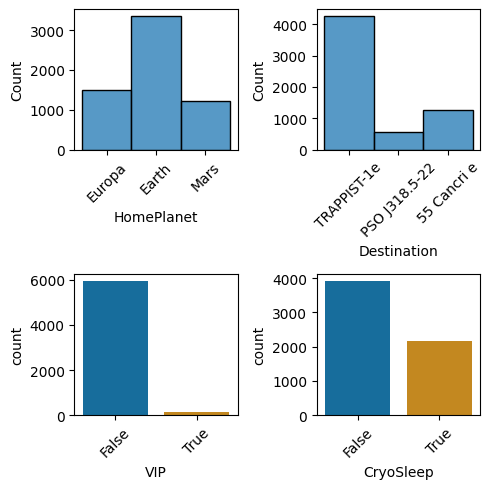

In [10]:
# Plot planet related histograms 
# Crear un espacio para dos gráficos uno al lado del otro
fig, axes = plt.subplots(2, 2, figsize=(5, 5))

# Primer gráfico: 
sns.histplot(ax=axes[0,0], data=EDA_train_raw_imputed, x='HomePlanet', multiple="stack", bins=10, palette='colorblind')
axes[0,0].tick_params(axis='x', rotation=45)

# Segundo gráfico
sns.histplot(ax=axes[0,1], data=EDA_train_raw_imputed, x='Destination', multiple="stack", bins=10, palette='colorblind')
axes[0,1].tick_params(axis='x', rotation=45)

# Tercer gráfico: 
sns.countplot(ax=axes[1,0], data=EDA_train_raw_imputed, x='VIP', palette='colorblind')
axes[1,0].tick_params(axis='x', rotation=45)


# Cuarto gráfico
sns.countplot(ax=axes[1,1], data=EDA_train_raw_imputed, x='CryoSleep', palette='colorblind')
axes[1,1].tick_params(axis='x', rotation=45)

# Ajustar el diseño para evitar solapamiento
plt.tight_layout()


#guardar el grafico 
plt.savefig('distribuciones simples.png')

# Mostrar el gráfico
plt.show()

➢ El origen más común fue Earth.


➢Hubo más viajeros que viajaron sin Cryo.


➢El destino de casi todos los pasajeros era TRAPPIST-1e.


➢Prácticamente todos los viajeros no eran VIP.

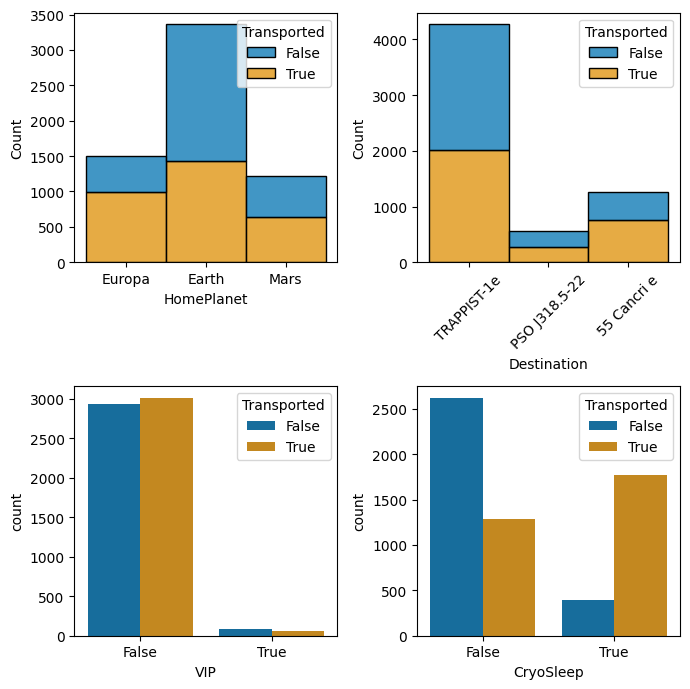

In [12]:
# Plot planet related histograms vs class


# Crear un espacio para dos gráficos uno al lado del otro
fig, axes = plt.subplots(2, 2, figsize=(7, 7))

# Primer gráfico: 
sns.histplot(ax=axes[0,0], data=EDA_train_raw_imputed, x='HomePlanet', hue='Transported', multiple="stack", bins=10, palette='colorblind')

# Segundo gráfico
sns.histplot(ax=axes[0,1],data=EDA_train_raw_imputed,x='Destination',hue='Transported',multiple="stack",bins=10,palette='colorblind')
# Rotamos las etiquetas del eje X (se solapaban)
axes[0,1].tick_params(axis='x', rotation=45)


# Primer gráfico: 
sns.countplot(ax=axes[1,0], data=EDA_train_raw_imputed, x='VIP', hue='Transported', palette='colorblind')

# Segundo gráfico
sns.countplot(ax=axes[1,1], data=EDA_train_raw_imputed, x='CryoSleep', hue='Transported', palette='colorblind')



# Evita solapamiento
plt.tight_layout()

#guardar el grafico 
plt.savefig('distribucion clase.png')

# Mostrar el gráfico
plt.show()

El planeta con mayor tasa de personas transportadas (dentro de su grupo) ha sido Europa con el 65,26% de su total, seguido de Mars con el 51,24% y finalmente Earth con el menor número de gente transportada de su total (42,83%).


El hecho de estar o no estar “cryo” parece que tuvo una alta relación con ser transportado. De los cryo, casi todos fueron transportados (82,26%) . Sin embargo, de los "no cryo" hubo muchos más no transportados (62,26%).


TRAPPIST-1E fue el destino final de la mayor parte de los viajeros. El 47,13% fueron transportados. 55 Cancri e, tuvo un mayor porcentaje de transportados dentro de su grupo, es decir, de la gente que terminó en ese destino, hubo más que fueron transportados 61,24% que no transportados 38,75%.


Si eras VIP, tenías más probabilidad de no ser transportado (0.65) que de ser transportado.

In [29]:
#calculo de probabilidades HomePlanet

# Crear una tabla de contingencia y normalizarla
tabla_contingencia_HomePlanet = pd.crosstab(EDA_train_raw_imputed['HomePlanet'], EDA_train_raw_imputed['Transported'], normalize='index')

# Mostrar la tabla de contingencia normalizada
print(tabla_contingencia_HomePlanet, "\n")

#--------
# Crear una tabla de contingencia y normalizarla
tabla_contingencia_Destination = pd.crosstab(EDA_train_raw_imputed['Destination'], EDA_train_raw_imputed['Transported'], normalize='index')

# Mostrar la tabla de contingencia normalizada
print(tabla_contingencia_Destination, "\n")

#------------
# Crear una tabla de contingencia y normalizarla
tabla_contingencia_VIP = pd.crosstab(EDA_train_raw_imputed['VIP'], EDA_train_raw_imputed['Transported'], normalize='index')

# Mostrar la tabla de contingencia normalizada
print(tabla_contingencia_VIP, "\n")

#----------
# Crear una tabla de contingencia y normalizarla
tabla_contingencia_CryoSleep= pd.crosstab(EDA_train_raw_imputed['CryoSleep'], EDA_train_raw_imputed['Transported'], normalize='index')

# Mostrar la tabla de contingencia normalizada
print(tabla_contingencia_CryoSleep)

Transported     False     True 
HomePlanet                     
Earth        0.570965  0.429035
Europa       0.339154  0.660846
Mars         0.480530  0.519470 

Transported       False     True 
Destination                      
55 Cancri e    0.383112  0.616888
PSO J318.5-22  0.508865  0.491135
TRAPPIST-1e    0.528760  0.471240 

Transported     False     True 
VIP                            
False        0.494291  0.505709
True         0.589147  0.410853 

Transported     False     True 
CryoSleep                      
False        0.664546  0.335454
True         0.189703  0.810297


### Crosstab crea una tabla de contingencia, es decir:

- Una tabla que cruza dos variables categóricas y cuenta cuántas veces ocurre cada combinación.

- Normalize convierte los conteos en proporciones.

In [13]:
# Crear una tabla de contingencia y normalizarla
tabla_contingencia = pd.crosstab([EDA_train_raw_imputed['HomePlanet'], EDA_train_raw_imputed['Destination']], EDA_train_raw_imputed['Transported'], normalize='index')

In [14]:
tabla_contingencia

Transported                  False     True 
HomePlanet Destination                      
Earth      55 Cancri e    0.497006  0.502994
           PSO J318.5-22  0.503937  0.496063
           TRAPPIST-1e    0.606550  0.393450
Europa     55 Cancri e    0.308800  0.691200
           PSO J318.5-22  0.230769  0.769231
           TRAPPIST-1e    0.365741  0.634259
Mars       55 Cancri e    0.398496  0.601504
           PSO J318.5-22  0.428571  0.571429
           TRAPPIST-1e    0.482464  0.517536

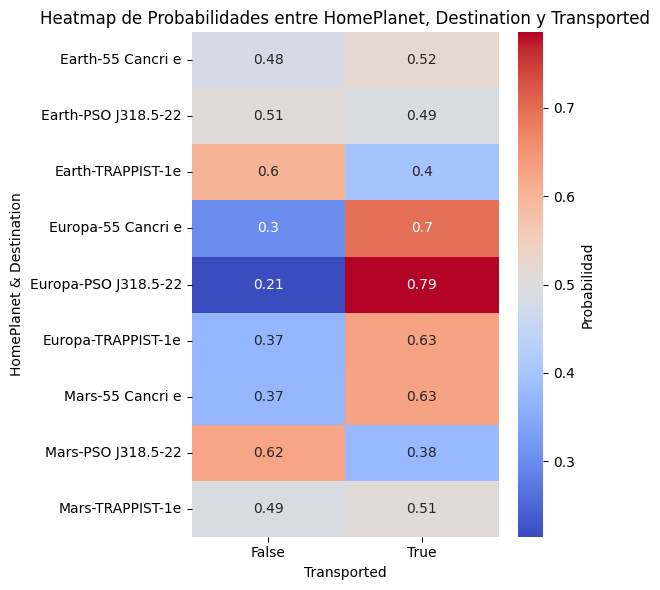

In [ ]:
#heatmap resumen

# Crear una tabla de contingencia y normalizarla
tabla_contingencia = pd.crosstab([EDA_train_raw_imputed['HomePlanet'], EDA_train_raw_imputed['Destination']], EDA_train_raw_imputed['Transported'], normalize='index')

# Convertir la tabla de contingencia a un DataFrame
probabilidades_df = tabla_contingencia.reset_index()

# Crear un heatmap
plt.figure(figsize=(6, 6))
sns.heatmap(probabilidades_df.set_index(['HomePlanet', 'Destination']), 
            annot=True, #Indica que se muestren los valores numéricos dentro de cada celda del heatmap.
            cmap='coolwarm', # mapa de colores
            cbar_kws={'label': 'Probabilidad'}) #Controla la barra de color lateral (la leyenda de colores).
plt.xlabel('Transported')
plt.ylabel('HomePlanet & Destination')
plt.title('Heatmap de Probabilidades entre HomePlanet, Destination y Transported')

plt.tight_layout()

#guardar el grafico 
plt.savefig('heatmap.png')

plt.show()

### Heatmap de probabilidades entre variables categóricas

En este bloque se construye una visualización que permite analizar la relación conjunta entre dos variables categóricas (`HomePlanet` y `Destination`) y la variable objetivo (`Transported`).

Primero, se crea una **tabla de contingencia** cruzando `HomePlanet` y `Destination` frente a `Transported`. Esto permite ver cuántas observaciones hay para cada combinación de categorías. Sin embargo, en lugar de trabajar con conteos absolutos, se normaliza por filas, lo que convierte los valores en **probabilidades**.

Esto significa que, para cada combinación de `HomePlanet` y `Destination`, se obtiene la proporción de personas que han sido transportadas o no. Es decir, responde a preguntas como: *“Dado que alguien viene de cierto planeta y va a cierto destino, ¿cuál es la probabilidad de que sea transportado?”*

Después, la tabla se reorganiza para facilitar su visualización, convirtiéndola en un formato adecuado para graficar.

Finalmente, se representa esta información mediante un **heatmap**. Este tipo de gráfico utiliza colores para mostrar la magnitud de los valores, permitiendo identificar patrones de forma visual:

- Colores más intensos indican probabilidades más altas o más bajas.
- Permite detectar rápidamente combinaciones de variables con mayor o menor probabilidad de `Transported`.
- Facilita comparar múltiples combinaciones al mismo tiempo.

En resumen, este proceso sirve para:
- Analizar relaciones entre varias variables categóricas a la vez.
- Detectar patrones relevantes para el modelo.
- Visualizar probabilidades de forma clara e intuitiva.

In [15]:
EDA_train_raw_imputed["Cabin"].values

<StringArray>
[ 'C/300/S',  'G/999/S', 'F/1132/P',  'B/198/P',  'B/331/S', 'F/1395/S',
  'G/150/S', 'G/1461/P',  'F/673/S', 'F/1463/P',
 ...
  'F/859/P',   'A/13/P',  'C/249/S',  'E/337/S',  'F/636/P',  'B/178/S',
 'F/1215/S', 'F/1370/P', 'G/1039/S',  'F/408/S']
Length: 6085, dtype: str

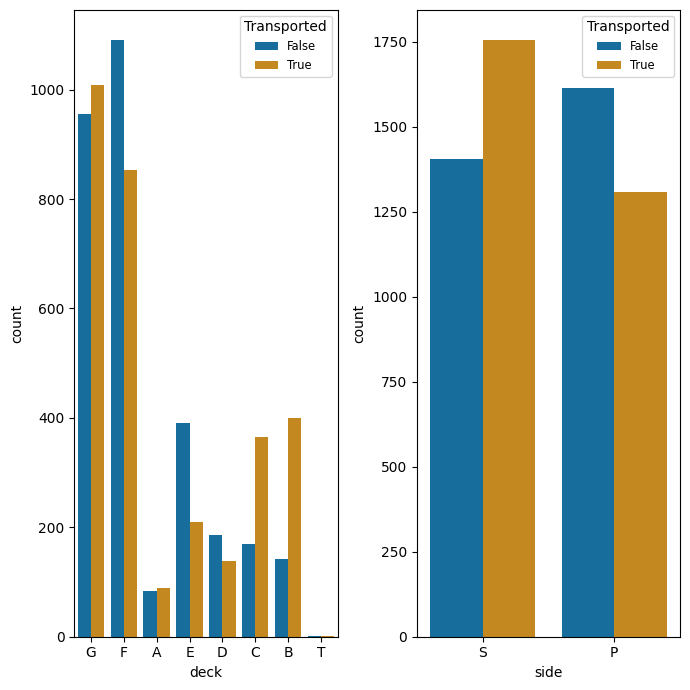

In [32]:
#Variable cabin. Al contener mucha info la separamos primero 

# La variable Cabin contiene varias piezas de información en una sola columna,
# separadas por "/". La descomponemos en:
# - deck (cubierta)
# - num (número de cabina)
# - side (lado: P o S)

cabin_df = pd.DataFrame()

# Extraemos la cubierta (parte antes del primer "/")
cabin_df['deck'] = EDA_train_raw_imputed["Cabin"].str.split("/").str[0]

# Extraemos el número de cabina (parte intermedia)
cabin_df['num'] = EDA_train_raw_imputed["Cabin"].str.split("/").str[1]

# Extraemos el lado (última parte)
cabin_df['side'] = EDA_train_raw_imputed["Cabin"].str.split("/").str[-1]


# ======================================
# Visualización
# ======================================
# Creamos dos gráficos lado a lado para comparar variables
fig, axes = plt.subplots(1, 2, figsize=(7, 7))

# Gráfico 1: distribución de pasajeros por cubierta (deck)
# Separamos por 'Transported' para ver diferencias entre clases
sns.countplot(
    ax=axes[0],
    data=cabin_df,
    x='deck',
    hue=EDA_train_raw_imputed['Transported'],
    palette='colorblind'
)

# Gráfico 2: distribución por lado de la nave (side)
sns.countplot(
    ax=axes[1],
    data=cabin_df,
    x='side',
    hue=EDA_train_raw_imputed['Transported'],
    palette='colorblind'
)

# Ajustamos layout para que no se solapen elementos
plt.tight_layout()

# Ajustar el diseño para evitar solapamiento
plt.tight_layout()
axes[0].legend(title='Transported', fontsize='small')
axes[1].legend(title='Transported', fontsize='small')

# Guardar el gráfico
plt.savefig('cabin_plot.png')

# Mostrar el gráfico
plt.show()

MÁS GRAFICOS DE INTERÉS

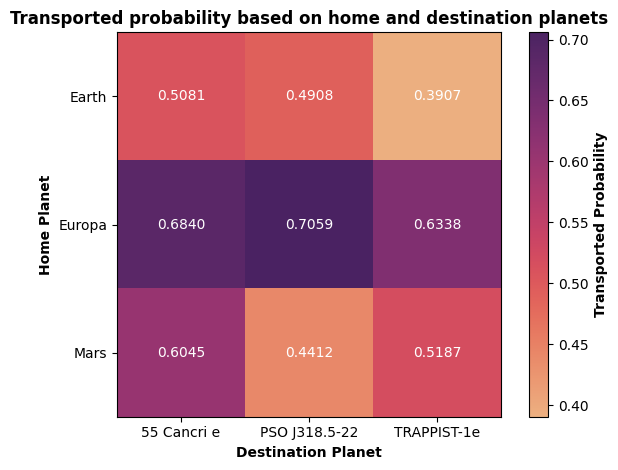

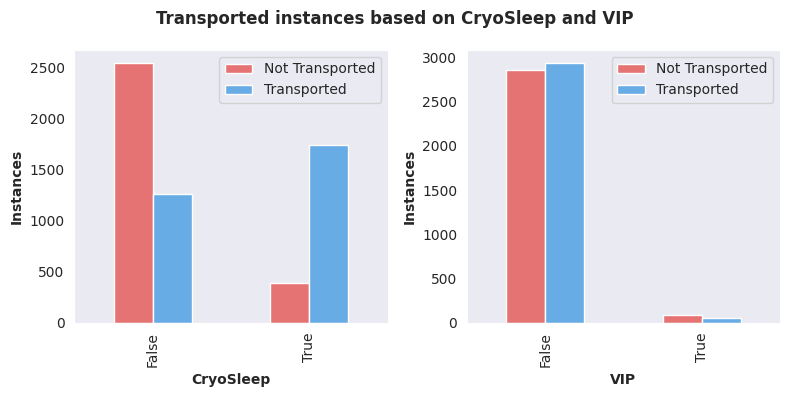

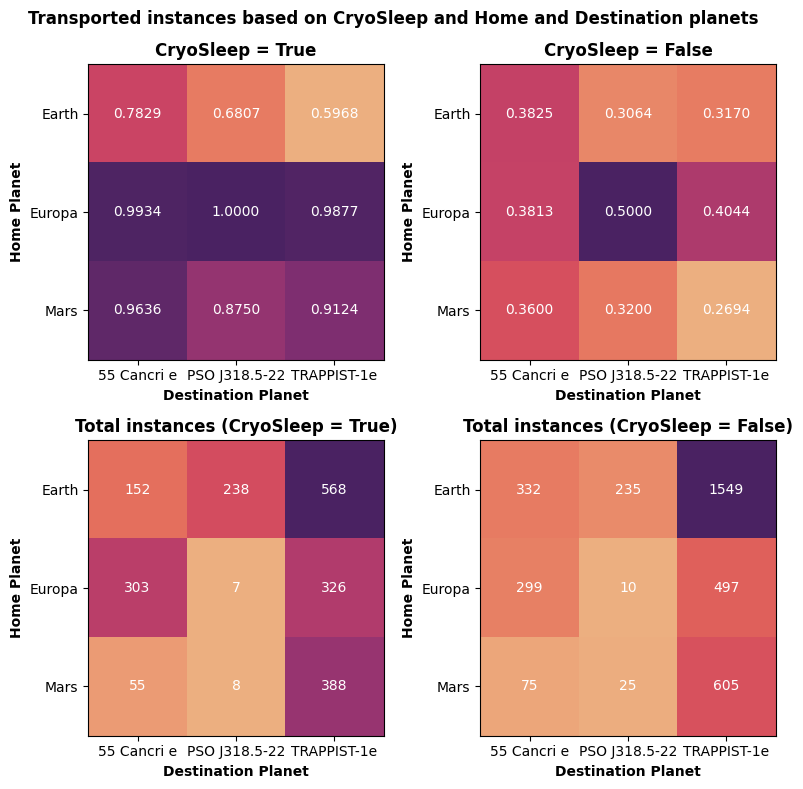

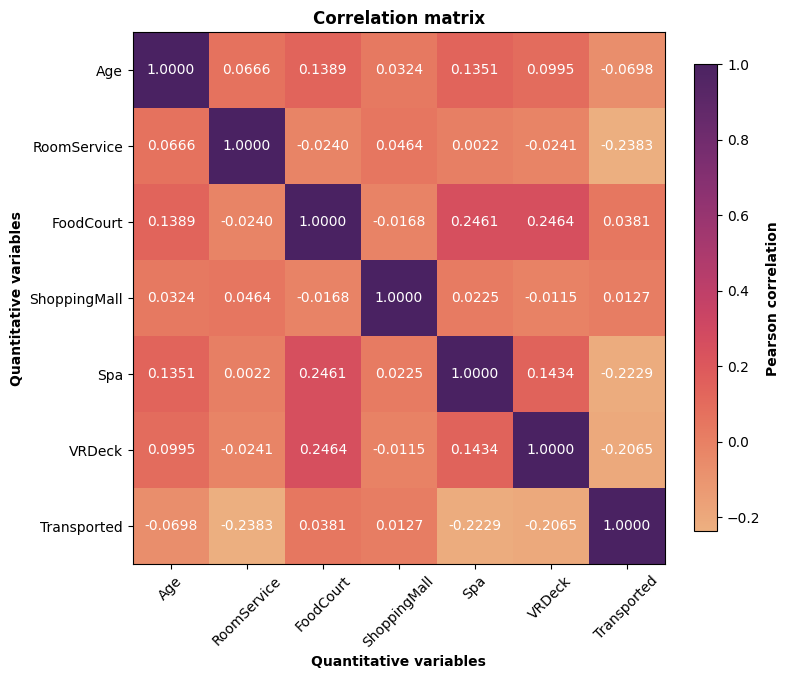

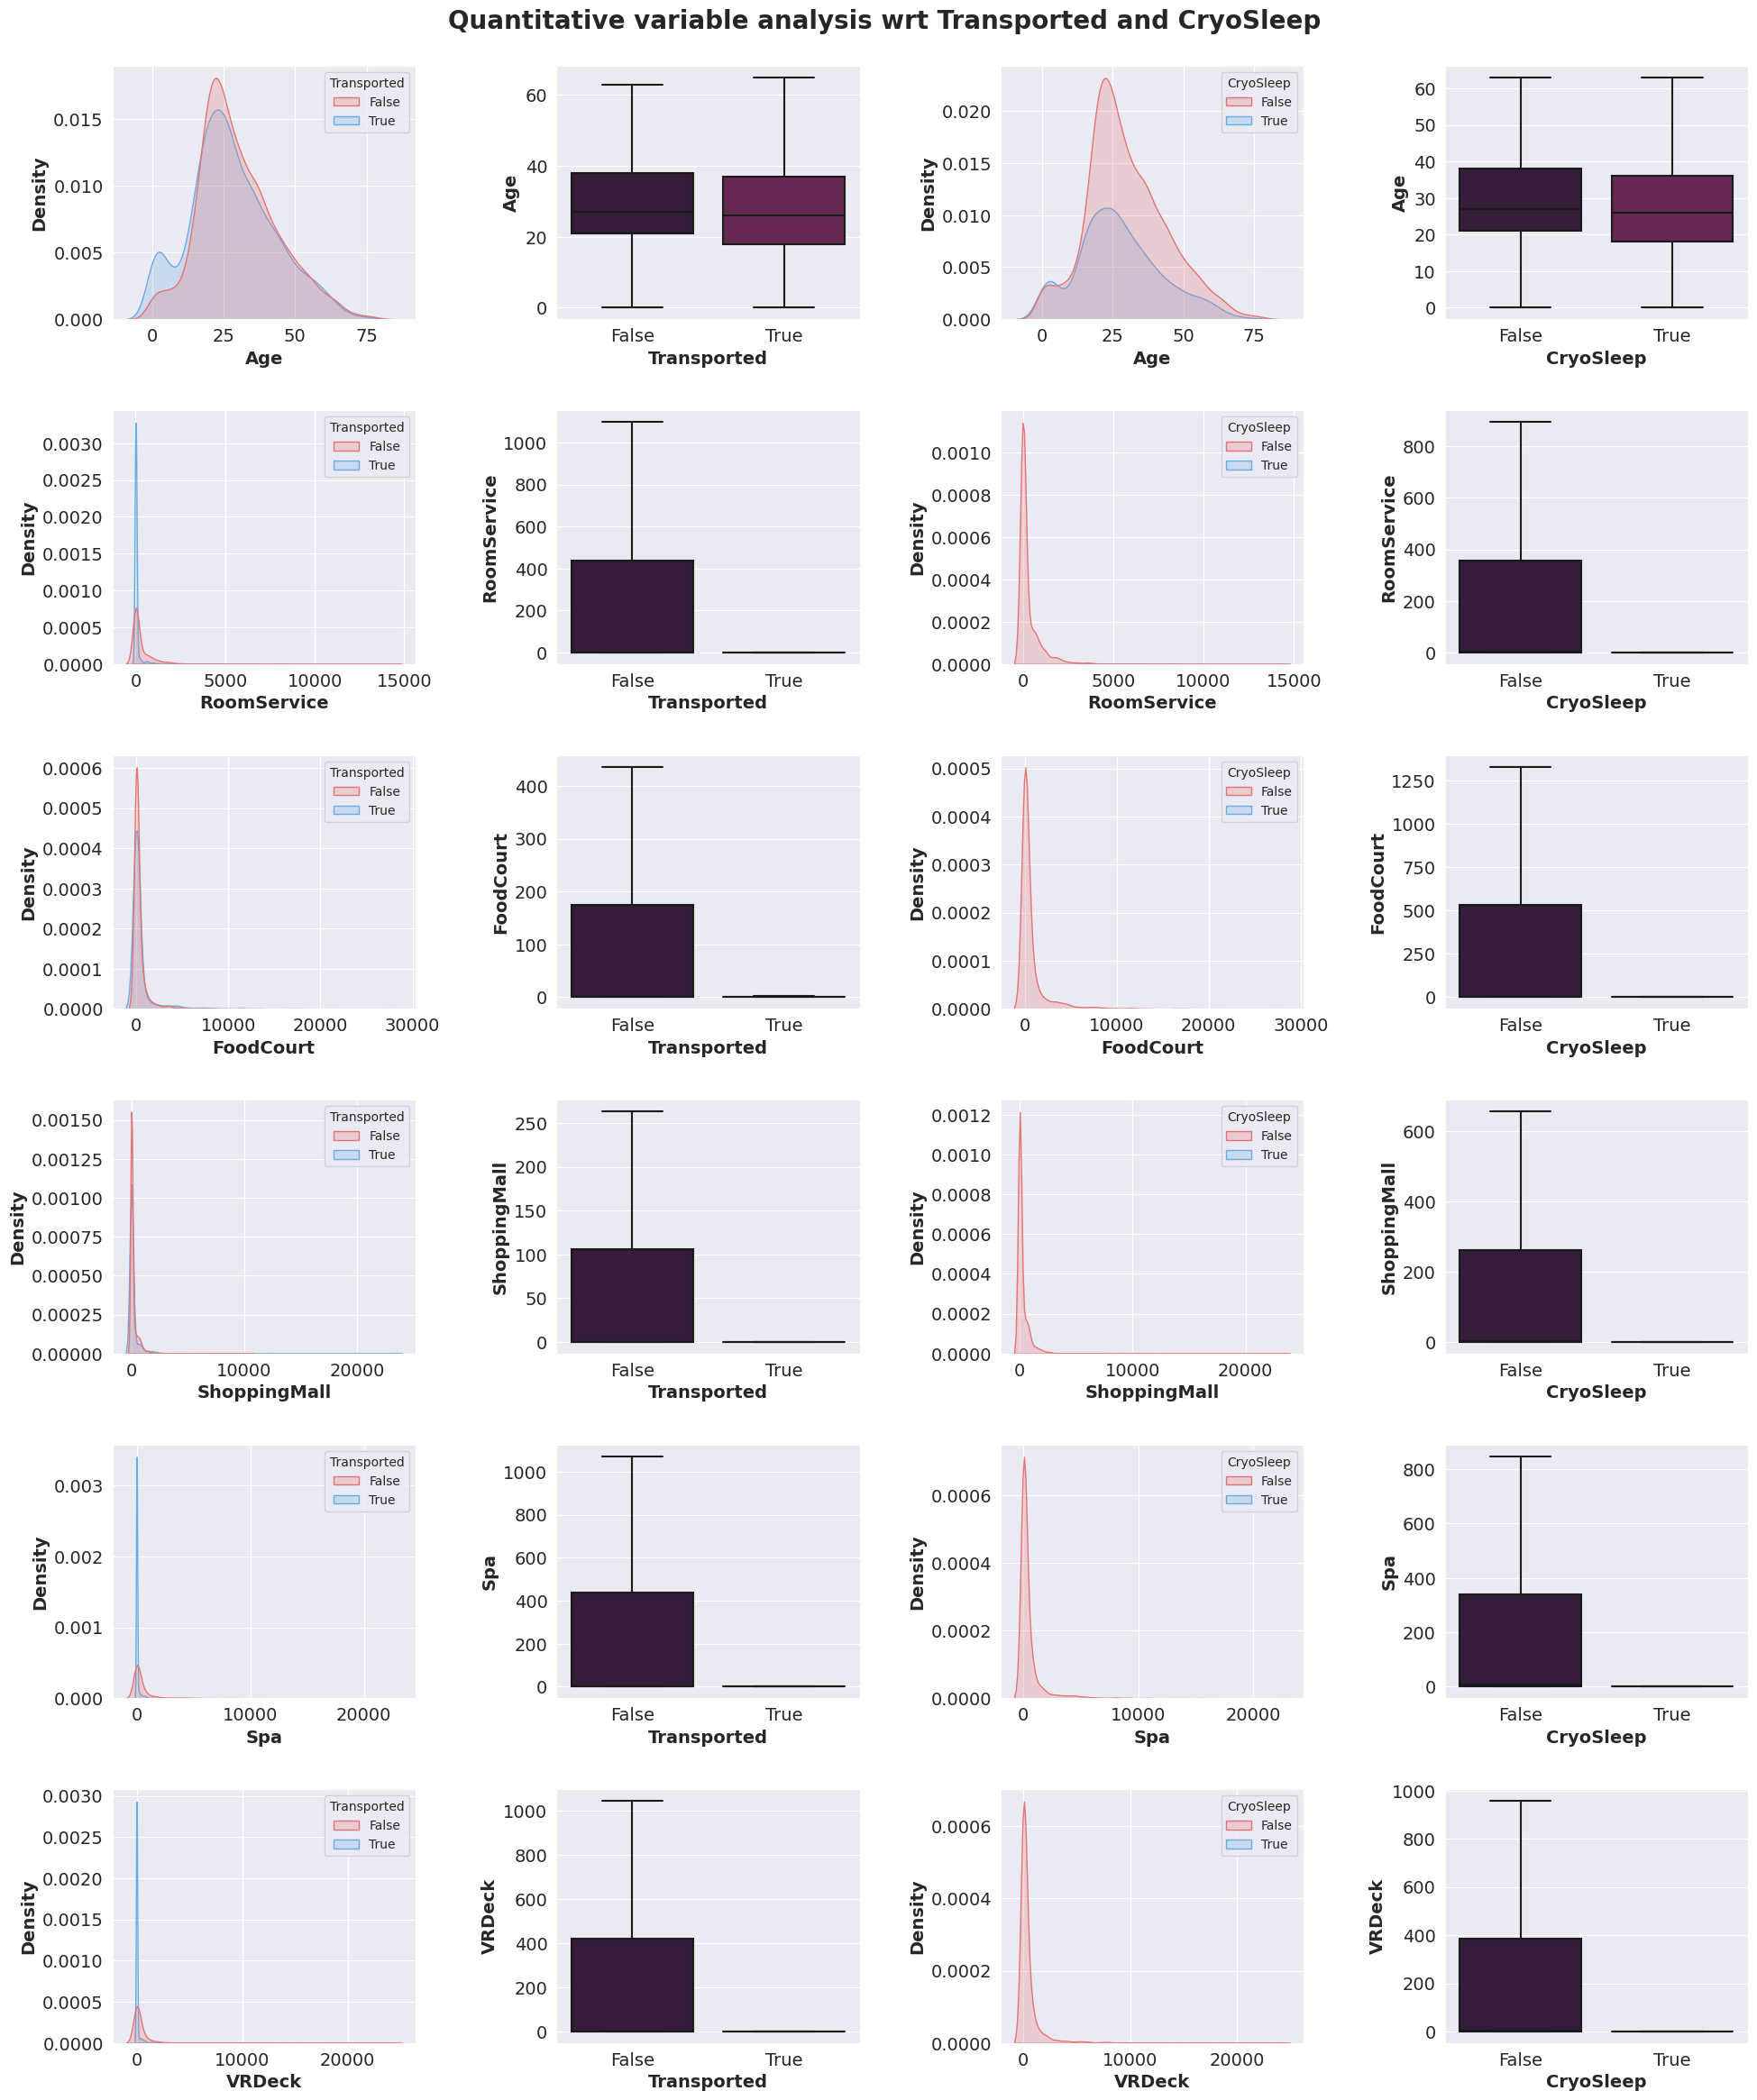

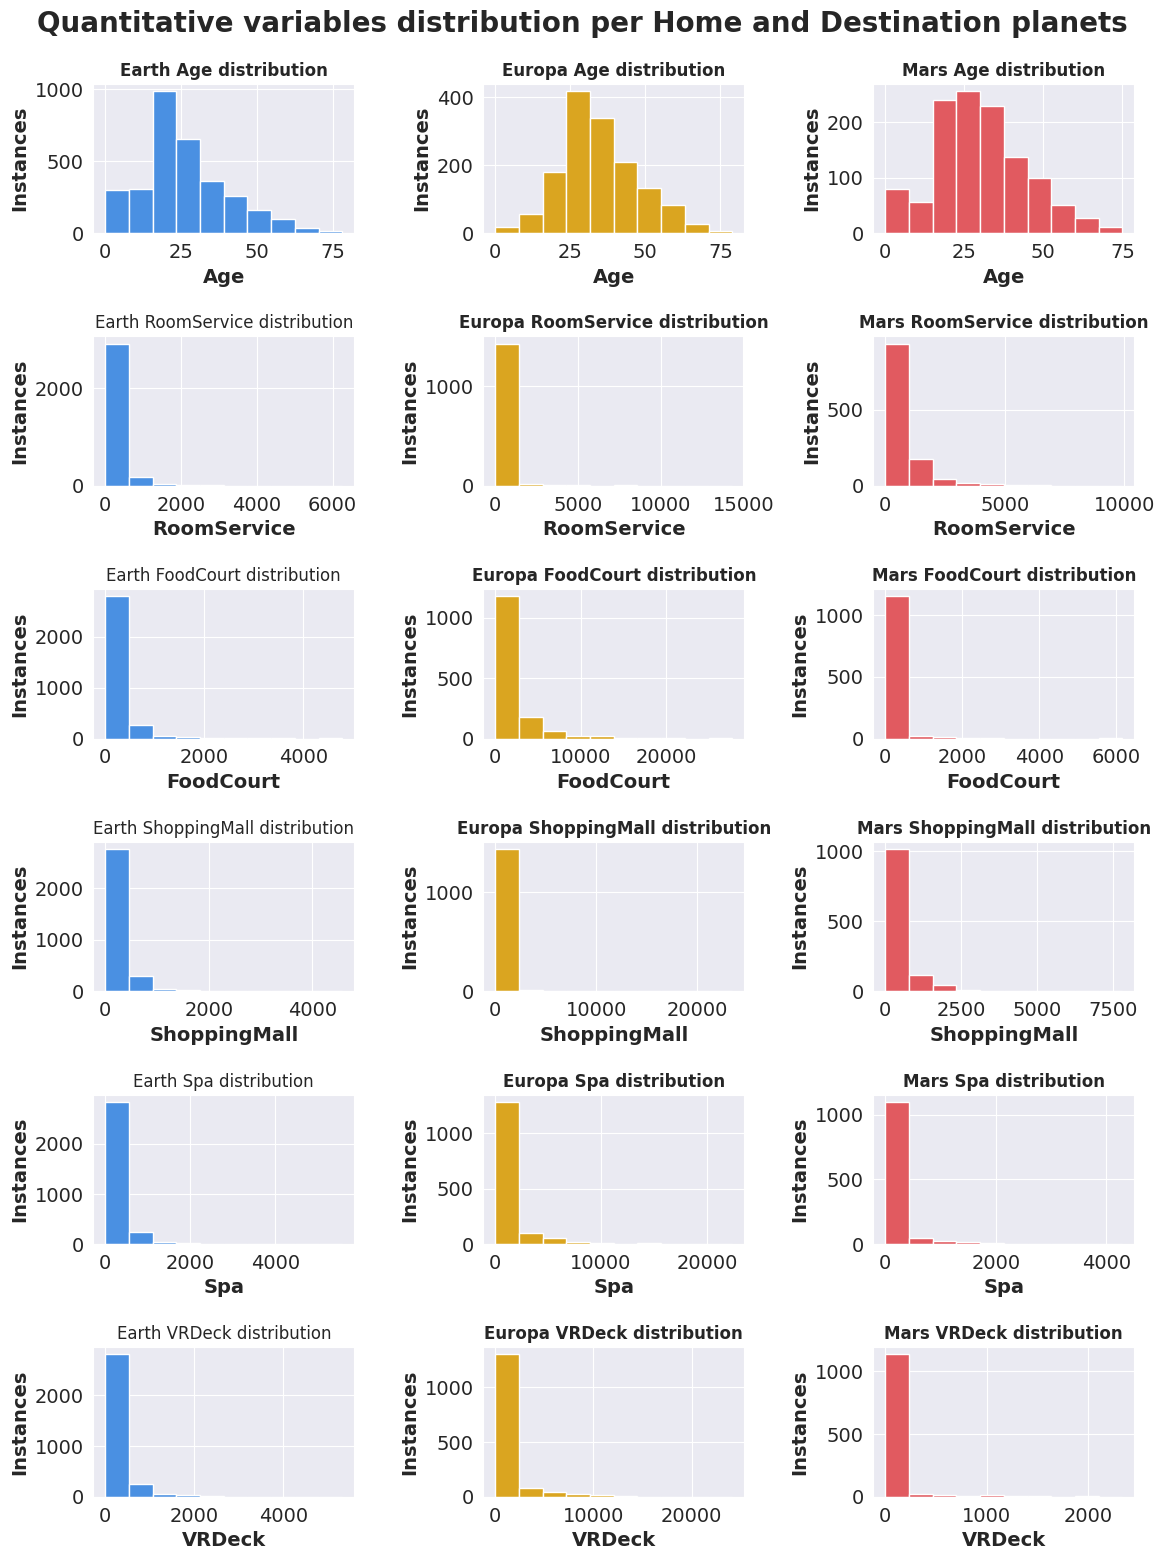

In [16]:
#feature engineering

#procesado de la columna cabin:
deck=EDA_train_raw_imputed["Cabin"].str.split("/").str[0]
# /num
num=EDA_train_raw_imputed["Cabin"].str.split("/").str[1]
# /side
side=EDA_train_raw_imputed["Cabin"].str.split("/").str[-1]

#eliminamos la columna name, ya que al haber sustituido por la moda todos los nombres NA (unos 200), el nombre sale repetido y se ven relaciones que no existen.
#realmente el nombre es como un ID, es una columna que de momento elimino porque no le veo utilidad
EDA_train_raw_imputed.drop('Name', axis=1, inplace=True)

#eliminamos la columna cabin y en su lugar generamos 3 independientes con deck, num, side
EDA_train_raw_imputed.drop('Cabin', axis=1, inplace=True)
EDA_train_raw_imputed['Cabin_Deck']=deck
EDA_train_raw_imputed['Cabin_Num']=num
EDA_train_raw_imputed['Cabin_Side']=side

#convertimos la columa "Cabin_Num a de tipo object a int"
EDA_train_raw_imputed['Cabin_Num'] = EDA_train_raw_imputed['Cabin_Num'].astype(int, errors='ignore')

#añadimos una columa que sume todos los gastos asociados a servicios durante el viaje
EDA_train_raw_imputed['Gastos']=EDA_train_raw_imputed[['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']].sum(axis=1)

#Ahora cruzaremos Gastos con Cryo, dado que alguien que va cryo no debería contratar un servicio de Spa, entre otros. Por ello corregimos el valor de CryoSleep
EDA_train_raw_imputed['Mod_CryoSleep'] = EDA_train_raw_imputed['CryoSleep'].copy() #duplicamos la columna CryoSleep y le ponemos Mod_CryoSleep
resultado = EDA_train_raw_imputed[(EDA_train_raw_imputed['Gastos'] == 0) & (EDA_train_raw_imputed['CryoSleep']==False)]
EDA_train_raw_imputed.loc[EDA_train_raw_imputed['Gastos'] == 0, 'Mod_CryoSleep'] = True
EDA_train_raw_imputed.drop('CryoSleep',axis=1,inplace=True)

#añadimos si la persona va sola o acompañada
EDA_train_raw_imputed['Personas_Grupo'] = EDA_train_raw_imputed.PassengerId.apply(lambda x: x.split('_')).apply(lambda x: x[0])
EDA_train_raw_imputed['Acompañado'] = ((EDA_train_raw_imputed['Personas_Grupo'].value_counts() > 1).reindex(EDA_train_raw_imputed['Personas_Grupo'])).tolist()
EDA_train_raw_imputed.drop('Personas_Grupo',axis=1,inplace=True)

#eliminamos passengerID
EDA_train_raw_imputed.drop('PassengerId',axis=1,inplace=True)

In [17]:
resultado

,PassengerId,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,Cabin_Deck,Cabin_Num,Cabin_Side,Gastos,Mod_CryoSleep
8440,9013_03,Earth,False,55 Cancri e,0.0,False,0.0,0.0,0.0,0.0,0.0,True,G,1461,P,0.0,False
5345,5714_01,Earth,False,TRAPPIST-1e,4.0,False,0.0,0.0,0.0,0.0,0.0,False,G,916,P,0.0,False
2419,2595_02,Mars,False,TRAPPIST-1e,4.0,False,0.0,0.0,0.0,0.0,0.0,True,F,533,P,0.0,False
2813,3032_03,Earth,False,TRAPPIST-1e,0.0,False,0.0,0.0,0.0,0.0,0.0,False,G,478,S,0.0,False
6771,7152_01,Earth,False,TRAPPIST-1e,8.0,False,0.0,0.0,0.0,0.0,0.0,True,G,1167,S,0.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
922,0989_01,Earth,False,TRAPPIST-1e,6.0,False,0.0,0.0,0.0,0.0,0.0,False,G,146,P,0.0,False
5188,5535_02,Earth,False,TRAPPIST-1e,0.0,False,0.0,0.0,0.0,0.0,0.0,True,G,893,S,0.0,False
691,0715_01,Europa,False,55 Cancri e,54.0,False,0.0,0.0,0.0,0.0,0.0,True,B,11,S,0.0,False
3234,3476_03,Earth,False,55 Cancri e,0.0,False,0.0,0.0,0.0,0.0,0.0,True,G,571,P,0.0,False


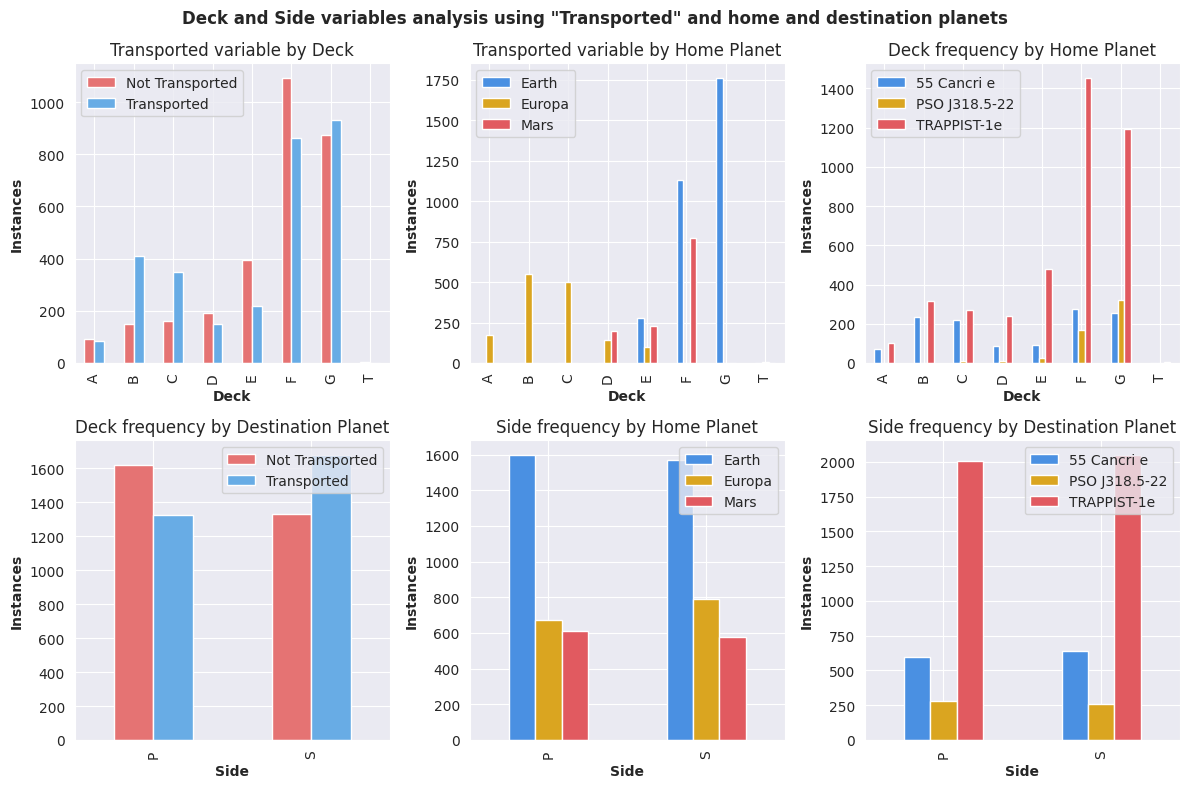

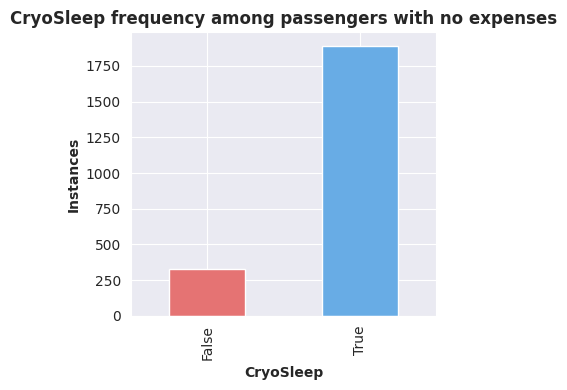

In [35]:
#visualizamos como queda el dataframe 
EDA_train_raw_imputed.head()

,HomePlanet,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,Cabin_Deck,Cabin_Num,Cabin_Side,Gastos,Mod_CryoSleep,Acompañado
6938,Earth,55 Cancri e,29.0,False,0.0,0.0,0.0,0.0,0.0,True,G,1194,S,0.0,True,False
6555,Earth,PSO J318.5-22,29.0,False,0.0,0.0,0.0,0.0,0.0,True,G,1126,S,0.0,True,False
6476,Earth,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,False,G,1111,P,0.0,True,False
3547,Mars,TRAPPIST-1e,54.0,False,0.0,0.0,0.0,0.0,0.0,True,F,786,P,0.0,True,True
4010,Europa,TRAPPIST-1e,25.0,False,0.0,0.0,0.0,0.0,0.0,True,A,38,P,0.0,True,False


In [36]:
EDA_train_raw_imputed.dtypes

HomePlanet           str
Destination          str
Age              float64
VIP               object
RoomService      float64
FoodCourt        float64
ShoppingMall     float64
Spa              float64
VRDeck           float64
Transported         bool
Cabin_Deck        object
Cabin_Num          int64
Cabin_Side        object
Gastos           float64
Mod_CryoSleep     object
Acompañado          bool
dtype: object

OUTLIERS


Un cuartil es un valor que divide un conjunto de datos ordenados en cuatro partes iguales. Se usa en estadística para entender cómo se distribuyen los datos y es clave en herramientas como el boxplot. Hay tres cuartiles principales: Q1, Q2 y Q3.

Los cuartiles:

Q1 (Primer cuartil):
    Es el valor por debajo del cual está el 25% de los datos.
    Si ordenas tus datos de menor a mayor, Q1 es el punto que deja un cuarto de los valores a su izquierda.

Q2 (Segundo cuartil o Mediana):
    Es el valor por debajo del cual está el 50% de los datos.
    Coincide con la mediana, el número que está justo en el medio cuando los datos están ordenados.

Q3 (Tercer cuartil):
    Es el valor por debajo del cual está el 75% de los datos.
    Marca el punto donde tres cuartos de los datos están a su izquierda.


Partes de un Boxplot:

Caja (Box):

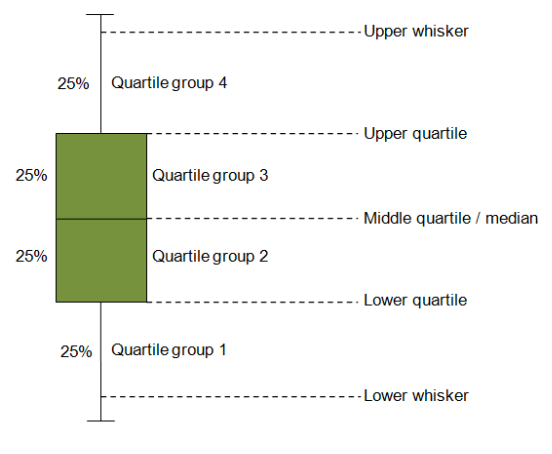

    La caja representa el rango intercuartílico (IQR), que es la distancia entre el primer cuartil (Q1) y el tercer cuartil (Q3).
    Q1 (25%): El valor por debajo del cual está el 25% de los datos.
    Q3 (75%): El valor por debajo del cual está el 75% de los datos.
    La caja muestra el 50% central de los datos (desde Q1 hasta Q3).

Línea dentro de la caja (Mediana):

    Es el segundo cuartil (Q2) o la mediana, el valor que divide los datos en dos mitades iguales (el 50% de los datos está por encima y el 50% por debajo).
    
Bigotes (Whiskers):

    Los bigotes se extienden desde los bordes de la caja (Q1 y Q3) hasta los valores mínimos y máximos que no se consideran outliers.
    Límite inferior del bigote: Q1 - (factor * IQR), donde el factor suele ser 1.5 por defecto, pero es ajustable.
    Límite superior del bigote: Q3 + (factor * IQR).
    Los bigotes muestran el rango de los datos que están dentro de un límite "normal", excluyendo los valores extremos.

Outliers (Valores atípicos):
    Son los puntos que quedan fuera de los bigotes.
    Se consideran outliers los valores que están por debajo de Q1 - (factor * IQR) o por encima de Q3 + (factor * IQR).
    En el gráfico, suelen aparecer como puntos o círculos individuales.

IQR (Rango Intercuartílico):

    Es la longitud de la caja: IQR = Q3 - Q1.
    Representa la dispersión del 50% central de los datos y se usa para calcular los límites de los bigotes y detectar outliers.

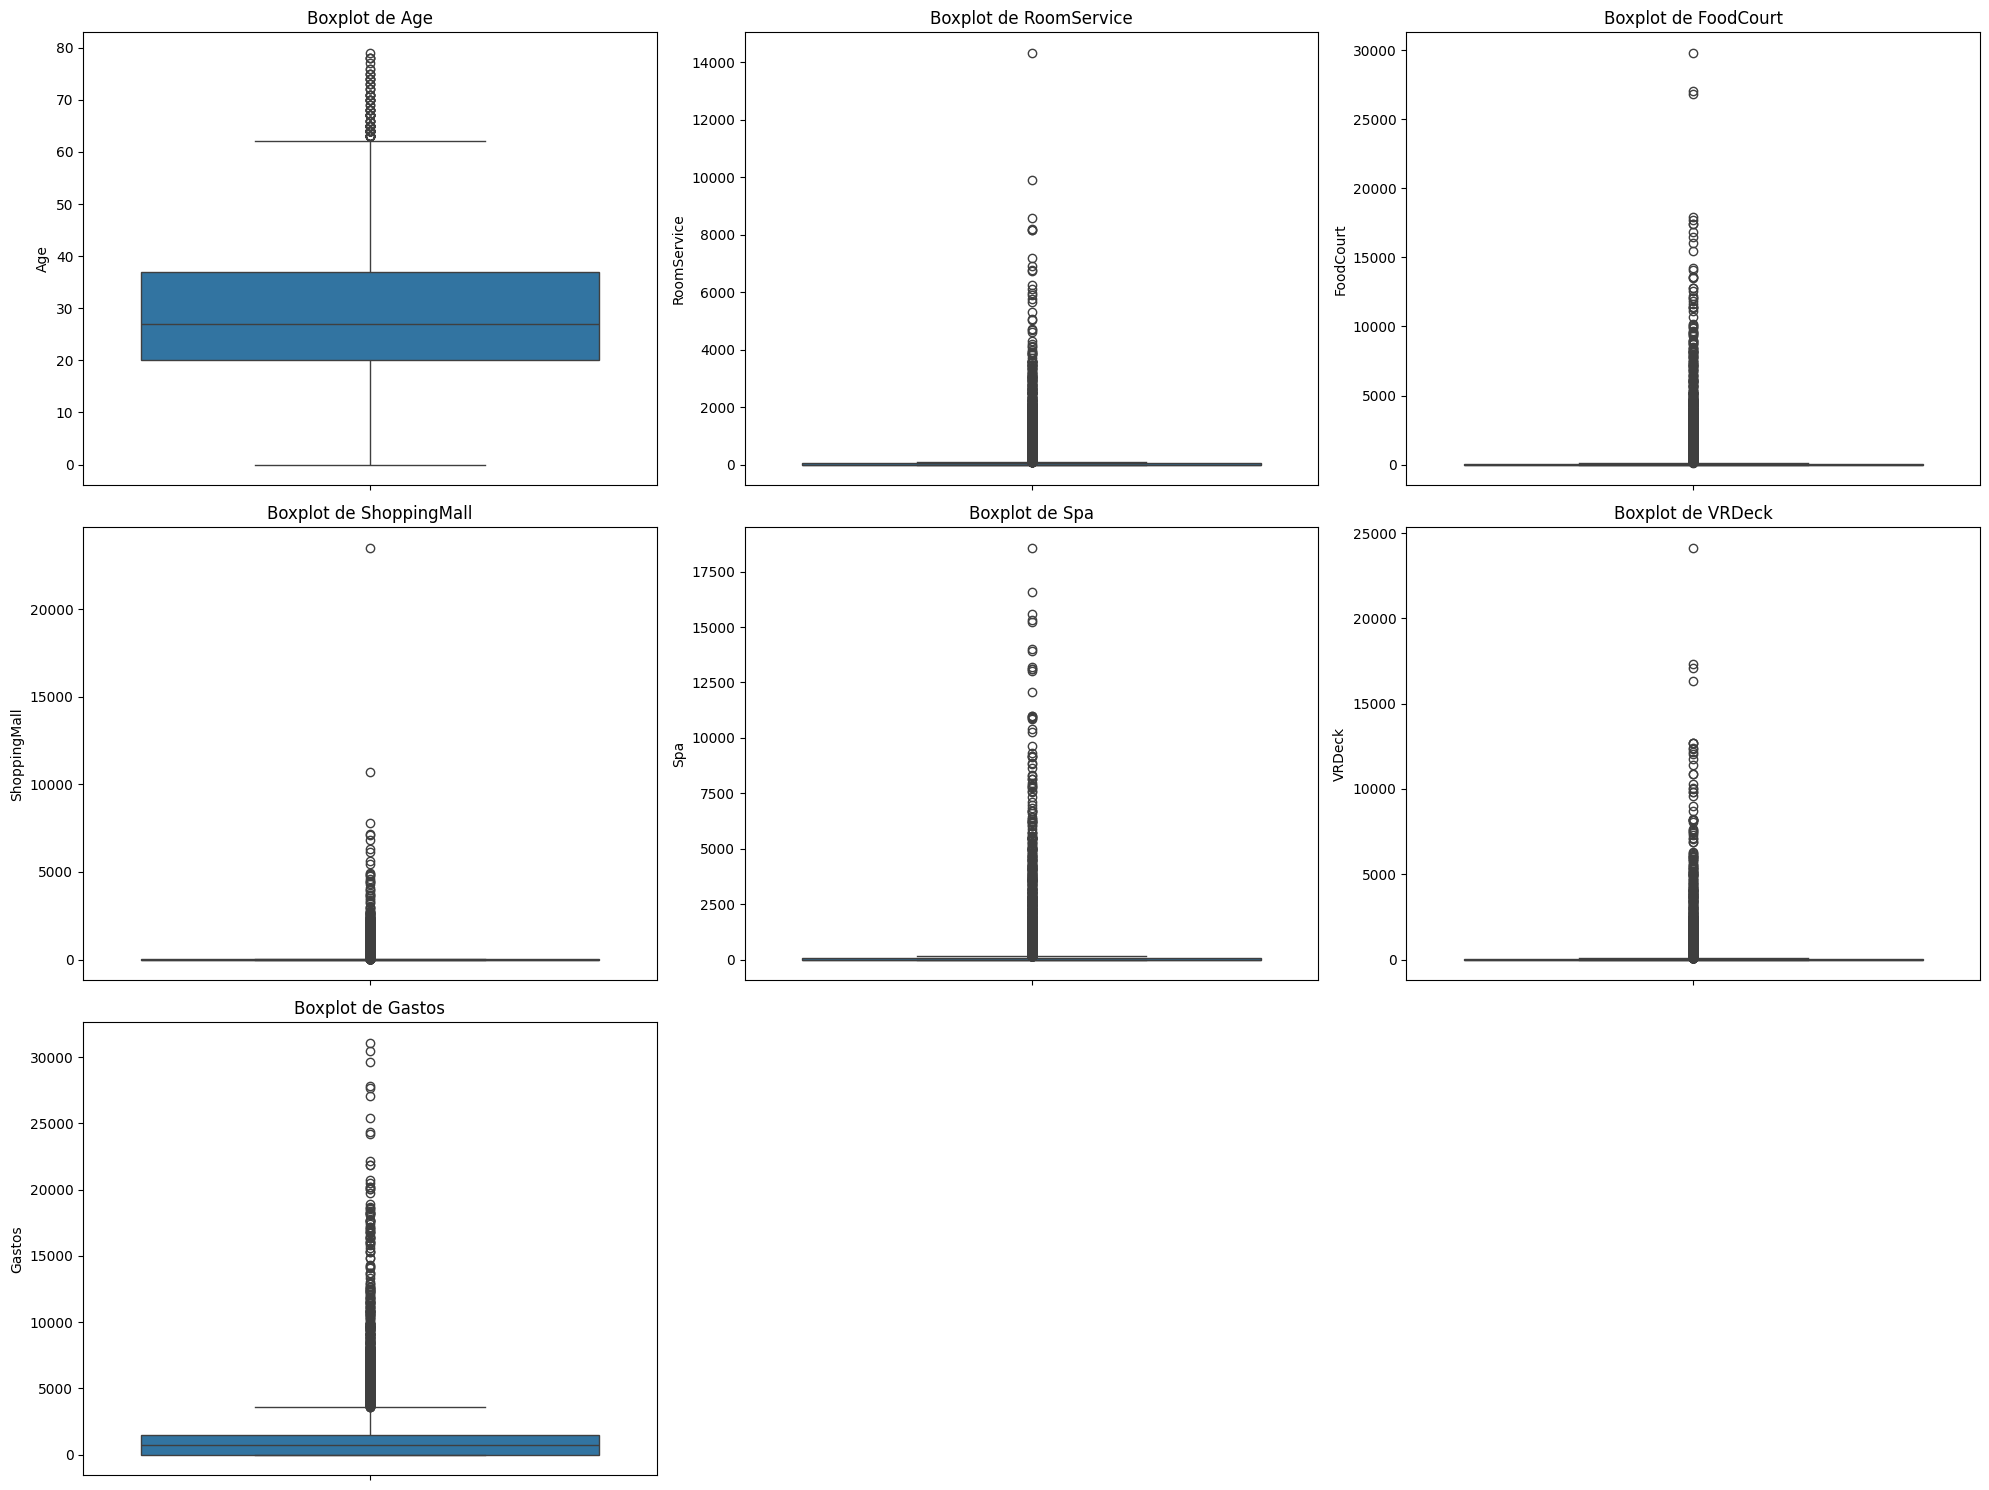

In [37]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Seleccionar solo las columnas numéricas del DataFrame
numeric_cols = EDA_train_raw_imputed.select_dtypes(include=['float64']).columns

# Definir el factor de IQR parametrizable (por defecto es 1.5, pero puedes ajustarlo)
iqr_factor = 1.5  # Puedes cambiar este valor según necesites

# Configurar el tamaño de la figura
plt.figure(figsize=(20, 15))

# Crear un boxplot para cada variable numérica
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 3, i)  # Ajusta la cuadrícula según el número de variables
    sns.boxplot(y=EDA_train_raw_imputed[col], whis=iqr_factor)
    plt.title(f'Boxplot de {col}')
    plt.ylabel(col)

# Ajustar el diseño para evitar solapamiento
plt.tight_layout()
plt.show()



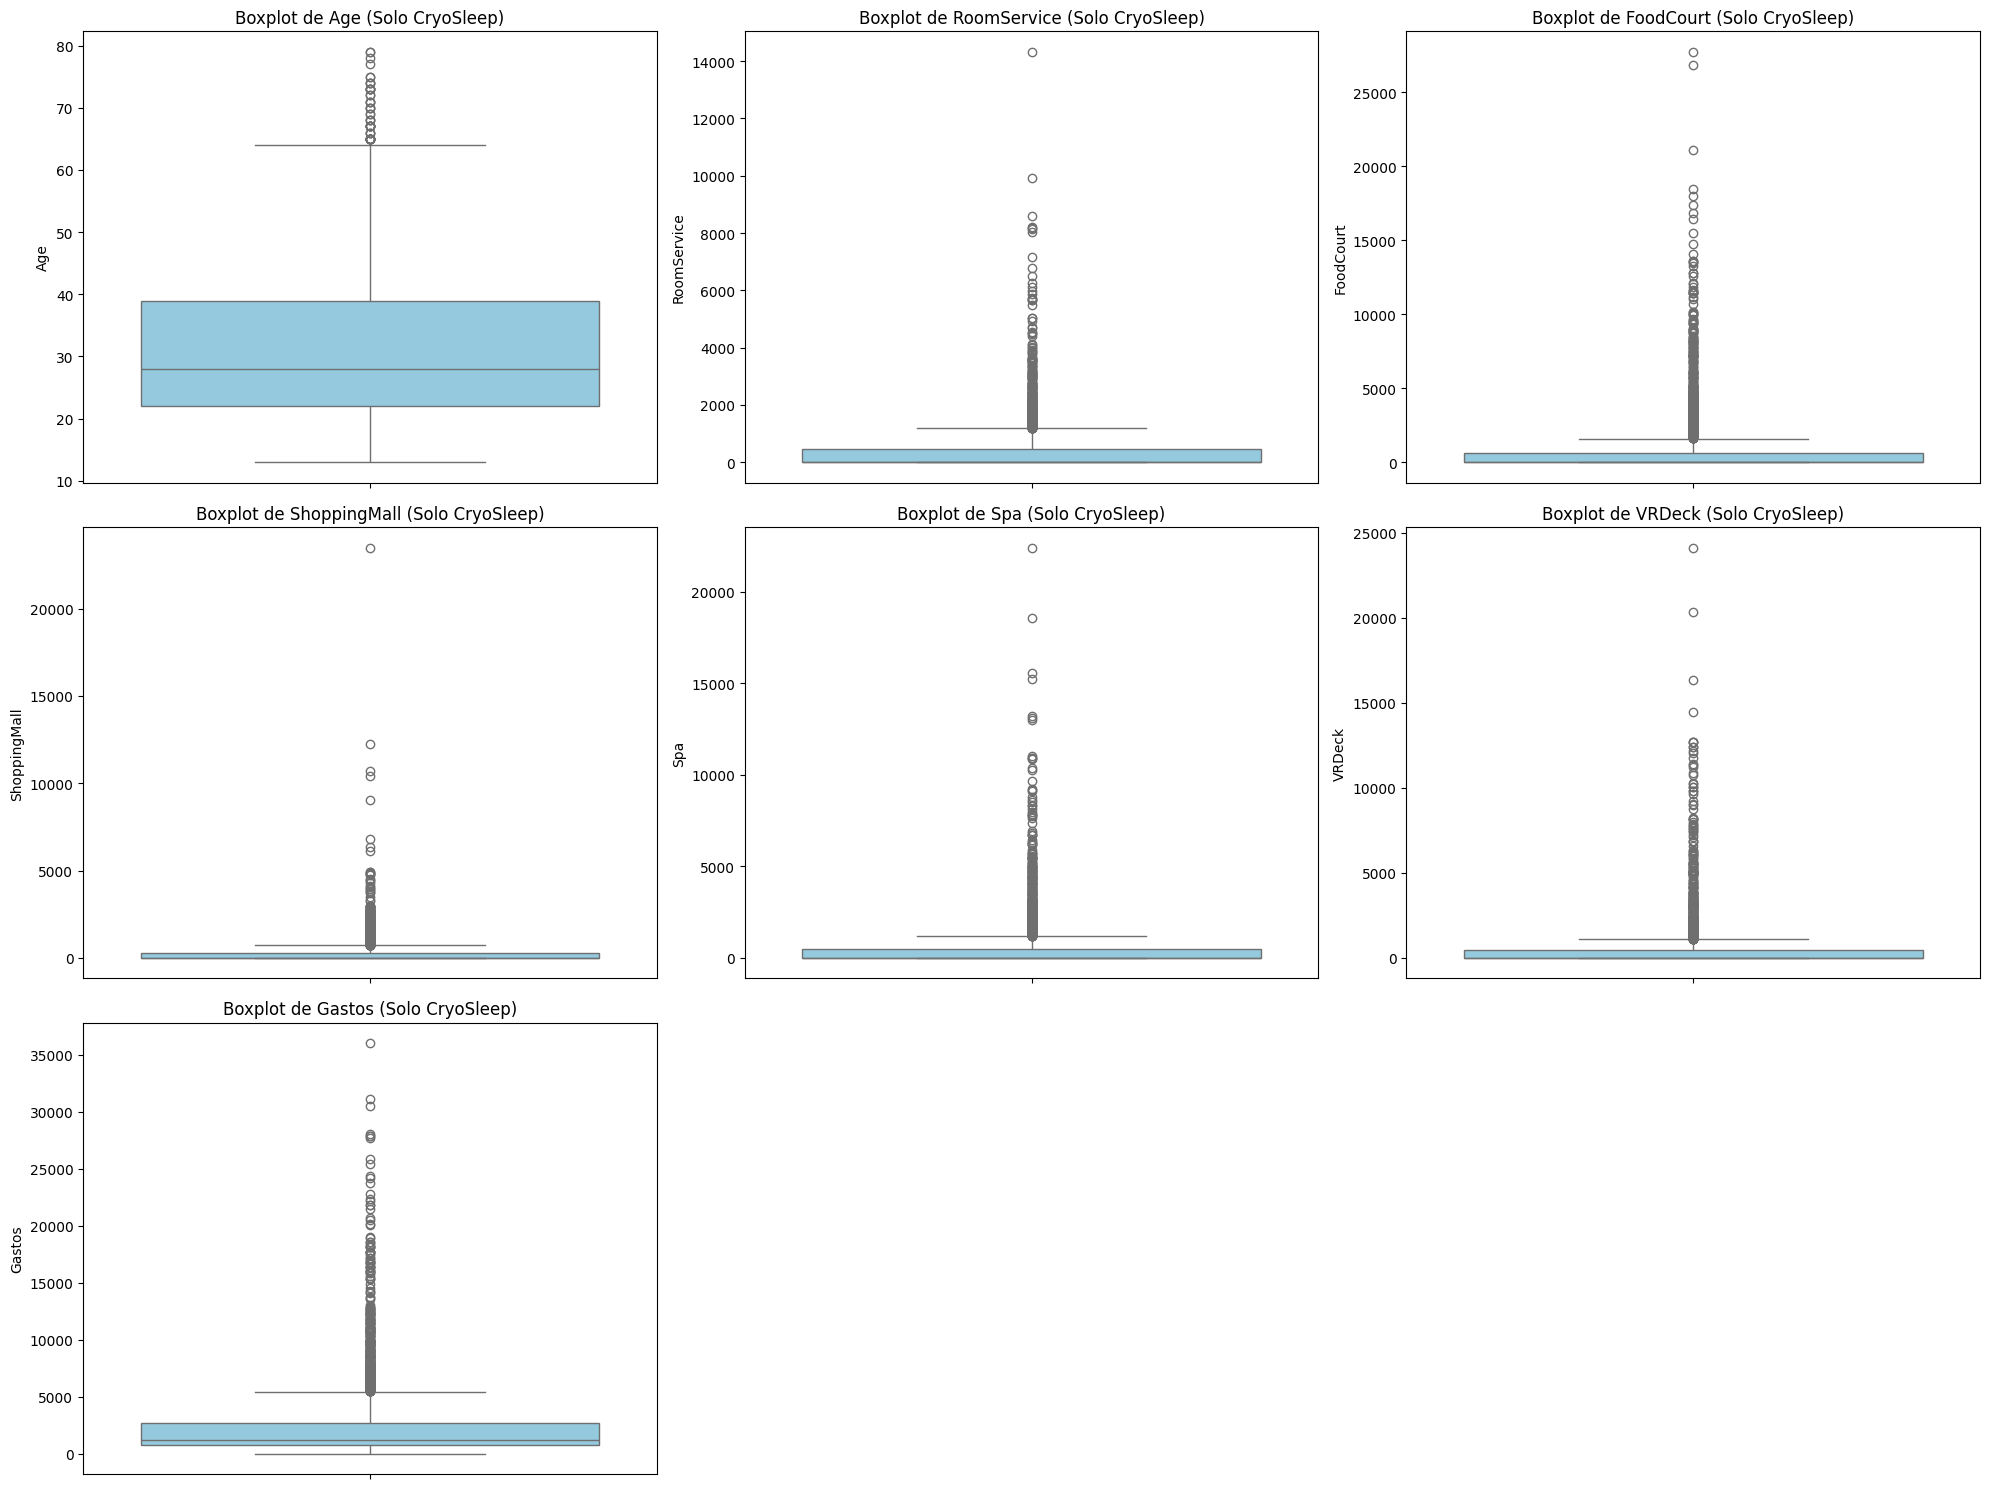

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Filtrar el DataFrame: Solo pasajeros en CryoSleep
df_filtrado = EDA_train_raw_imputed[EDA_train_raw_imputed['Mod_CryoSleep'] == False]

# Seleccionar solo las columnas numéricas del DataFrame filtrado
numeric_cols = df_filtrado.select_dtypes(include=['float64']).columns

# Definir el factor de IQR parametrizable
iqr_factor = 1.5 

# Configurar el tamaño de la figura
plt.figure(figsize=(20, 15))

# Crear un boxplot para cada variable numérica usando el DF filtrado
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(3, 3, i)
    # Usamos df_filtrado en lugar del original
    sns.boxplot(y=df_filtrado[col], whis=iqr_factor, color='skyblue') 
    plt.title(f'Boxplot de {col} (Solo CryoSleep)')
    plt.ylabel(col)

# Ajustar el diseño para evitar solapamiento
plt.tight_layout()
plt.show()

De los plots arriba mostrados, se pueden obtener las siguientes conclusiones:

➢La variable Age es la única que sigue una distribución normal, en el resto de variables la distribución está desplazada hacia la izquierda.

➢En todas las variables existen outliers, como se pueden ver en los boxplots.

En este análisis inicial, se ha aplicado la técnica de reducción de outliers siguiendo el criterio IQR. Para ellos, se calcula el espacio intercuartílico Q3-Q1 y se multiplica por un factor *1,5. Todo valor que esté fuera de ese intervalo, se considera outlier y se sustituye por su mediana de la columna. **Este approach, no se sigue en el pipeline final, dado
que se ha comprobado que el hecho de cambiar estos outliers por mediana repercute negativamente en el performance del modelo (del orden de un 5% menos)**. A modo de ejemplo, se hace un plot del antes y después de la variable Age (Se ha hecho lo mismo en el resto):

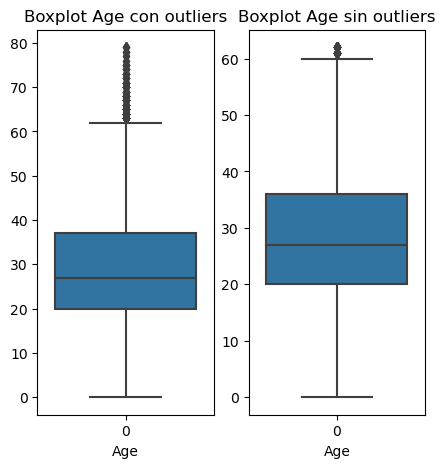

Se puede apreciar el efecto de cambiar los outliers por la mediana, que desplazan la caja hacia arriba. Si se usase la media, el desplazamiento sería mayor dado que es más sensible a outliers.
En el caso de las variables asociadas a los distintos servicios, los boxplots como se pueden ver en la Figura 6 Figura
77son más exagerados en cuando a outliers para todos los casos. Al no seguir una distribución normal y estar los datos concentrados en una región muy concreta (en 0), cualquier valos mínimamente fuera de ese rango ya se considera anomalía. Si por ejemplo en el caso de “RoomService” se quisiera sustituír por la mediana, la cual está en 0, se perdería la poca información que puede aportar la variable. Si se quisiera sustituir por la media, que está en 3,13 poca información aportaría dado que los gastos se mueven en miles. La técnica que se ha utilizado en el pipeline es de “Winsorizing”, que remplaza los outliers con los valores más cercanos que no son extremos. Sin embargo también se ha obtenido un peor score. En el score final, se decide dejar los valores sin modificar ni eliminar ningún outlier.

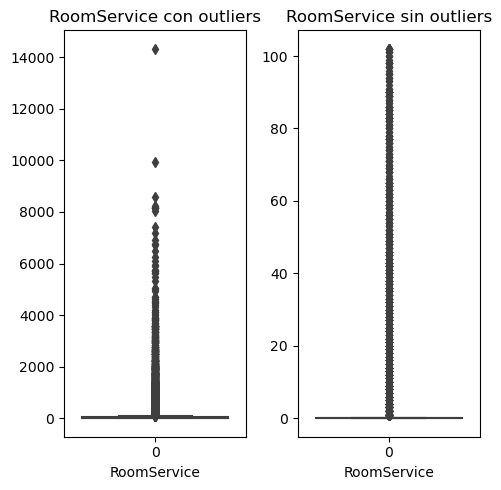

Otra técnica aplicada para estos datos numéricos asociados a los costes ha sido la de transformación logarítmica de la distribución. Con esto se ha tratado de hacer la distribución más simétrica. El score ha sido sensiblemente inferior al mejor score obtenido en Kaggle.

## Escalado de variables: interpretación estadística

Cuando se aplica un método como StandardScaler, cada variable se transforma según la siguiente expresión:

$$
x_{scaled} = \frac{x - \mu}{\sigma}
$$

donde:
- $\mu$ es la media de la variable  
- $\sigma$ es la desviación estándar  

Como resultado, la variable transformada tiene:
- media igual a 0  
- desviación estándar igual a 1  

---

## Motivos para aplicar el escalado

### 1. Igualar las escalas de las variables

En muchos conjuntos de datos, las variables pueden tener rangos muy distintos. Por ejemplo:
- Edad: valores entre 0 y 100  
- Ingresos: valores entre 0 y 100000  

Sin escalado, los modelos pueden asignar mayor importancia a las variables con valores más grandes simplemente por su magnitud. El escalado elimina este efecto y sitúa todas las variables en una escala comparable.

---

### 2. Evitar sesgos en el cálculo de distancias

Algunos algoritmos se basan en medidas de distancia, como:
- K-Nearest Neighbors (KNN)  
- K-Means  
- Support Vector Machines (SVM)  

En estos casos, si una variable tiene valores mucho mayores que otra, dominará el cálculo de la distancia. El escalado asegura que todas las variables contribuyan de forma equilibrada.

---

### 3. Mejorar la convergencia en métodos de optimización

Modelos como:
- regresión lineal o logística  
- redes neuronales  

utilizan algoritmos de optimización como el descenso por gradiente. Si las variables no están escaladas, el espacio de optimización puede estar distorsionado, lo que provoca:
- convergencia más lenta  
- trayectorias ineficientes  

El escalado hace que el espacio sea más uniforme y facilita una convergencia más rápida y estable.

---

### 4. Interpretación estadística de los valores

Tras el escalado:
- un valor de 1 indica que la observación está a una desviación estándar por encima de la media  
- un valor de -1 indica que está por debajo de la media  

Esto permite interpretar todas las variables en una misma escala relativa.

---

## Cuándo es necesario aplicar escalado

Es especialmente importante en modelos basados en distancias o en optimización:
- KNN  
- SVM  
- regresión lineal y logística  
- redes neuronales  
- PCA  
- clustering  

En cambio, no es relevante en modelos basados en árboles, como:
- árboles de decisión  
- random forest  
- gradient boosting  

Estos modelos no dependen de distancias ni de la escala de las variables.

---

## Resumen

El escalado permite que todas las variables tengan una distribución comparable, evitando que la magnitud de algunas influya indebidamente en el modelo y mejorando tanto la estabilidad como la eficiencia del aprendizaje.

In [38]:
# ======================================
# ESCALADO Y ONE-HOT ENCODING
# ======================================
# Partimos del dataset ya imputado (sin NaN)
EDA_train_raw_imputed_scaled_oh = EDA_train_raw_imputed.copy()

# Eliminamos Cabin_Num porque es una variable con demasiados valores únicos
# → al hacer one-hot generaría muchísimas columnas (alta dimensionalidad)
EDA_train_raw_imputed_scaled_oh.drop('Cabin_Num', axis=1, inplace=True)


# ======================================
# Identificar columnas numéricas y categóricas
# ======================================
# Esto nos permite aplicar transformaciones distintas a cada tipo

EDA_updated_numeric_columns = list(
    EDA_train_raw_imputed_scaled_oh.select_dtypes(include=['number']).columns
)
print('NUM', EDA_updated_numeric_columns)

EDA_updated_cat_columns = list(
    EDA_train_raw_imputed_scaled_oh.select_dtypes(include=['object']).columns
)
print('CAT', EDA_updated_cat_columns)


# ======================================
# ESCALADO DE VARIABLES NUMÉRICAS
# ======================================
# StandardScaler:
# - centra los datos (media = 0)
# - los escala (desviación típica = 1)
# Esto es útil para muchos modelos (ej: regresión, KNN, SVM)

scaler = StandardScaler()

# fit_transform:
# - fit → calcula media y desviación estándar en los datos
# - transform → aplica la transformación usando esos valores
EDA_train_raw_imputed_scaled_oh[EDA_updated_numeric_columns] = (
    scaler.fit_transform(EDA_train_raw_imputed_scaled_oh[EDA_updated_numeric_columns])
)


# ======================================
# ONE-HOT ENCODING DE VARIABLES CATEGÓRICAS
# ======================================
# get_dummies:
# Convierte variables categóricas en variables binarias (0/1)
# Ejemplo:
#   HomePlanet = Earth/Mars →
#   HomePlanet_Earth, HomePlanet_Mars

EDA_train_raw_imputed_scaled_oh = pd.get_dummies(
    EDA_train_raw_imputed_scaled_oh,
    columns=EDA_updated_cat_columns,
    drop_first=True  # evita multicolinealidad (elimina una categoría base)
)


NUM ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Gastos']
CAT ['HomePlanet', 'Destination', 'VIP', 'Cabin_Deck', 'Cabin_Side', 'Mod_CryoSleep']


C:\Users\sgomezvi\AppData\Local\Temp\ipykernel_15820\1462506167.py:13: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  EDA_updated_cat_columns = list(EDA_train_raw_imputed_scaled_oh.select_dtypes(include=['object']).columns)


In [39]:
EDA_train_raw_imputed_scaled_oh.dtypes

Age                          float64
RoomService                  float64
FoodCourt                    float64
ShoppingMall                 float64
Spa                          float64
VRDeck                       float64
Transported                     bool
Gastos                       float64
Acompañado                      bool
HomePlanet_Europa               bool
HomePlanet_Mars                 bool
Destination_PSO J318.5-22       bool
Destination_TRAPPIST-1e         bool
VIP_True                        bool
Cabin_Deck_B                    bool
Cabin_Deck_C                    bool
Cabin_Deck_D                    bool
Cabin_Deck_E                    bool
Cabin_Deck_F                    bool
Cabin_Deck_G                    bool
Cabin_Deck_T                    bool
Cabin_Side_S                    bool
Mod_CryoSleep_True              bool
dtype: object

In [85]:
EDA_train_raw_imputed_scaled_oh.head()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Transported,Gastos,Acompañado,HomePlanet_Europa,...,VIP_True,Cabin_Deck_B,Cabin_Deck_C,Cabin_Deck_D,Cabin_Deck_E,Cabin_Deck_F,Cabin_Deck_G,Cabin_Deck_T,Cabin_Side_S,Mod_CryoSleep_True
0,0.711945,-0.333105,-0.281027,-0.283579,-0.270626,-0.263003,False,-0.514066,False,True,...,False,True,False,False,False,False,False,False,False,True
1,-0.334037,-0.168073,-0.275387,-0.241771,0.217158,-0.224205,True,-0.251479,False,False,...,False,False,False,False,False,True,False,False,True,False
2,2.036857,-0.268001,1.959998,-0.283579,5.695623,-0.219796,False,3.190333,True,True,...,True,False,False,False,False,False,False,False,True,False
3,0.293552,-0.333105,0.523010,0.336851,2.687176,-0.092818,False,1.332604,True,True,...,False,False,False,False,False,False,False,False,True,False
4,-0.891895,0.125652,-0.237159,-0.031059,0.231374,-0.261240,True,-0.124824,False,False,...,False,False,False,False,False,True,False,False,True,False


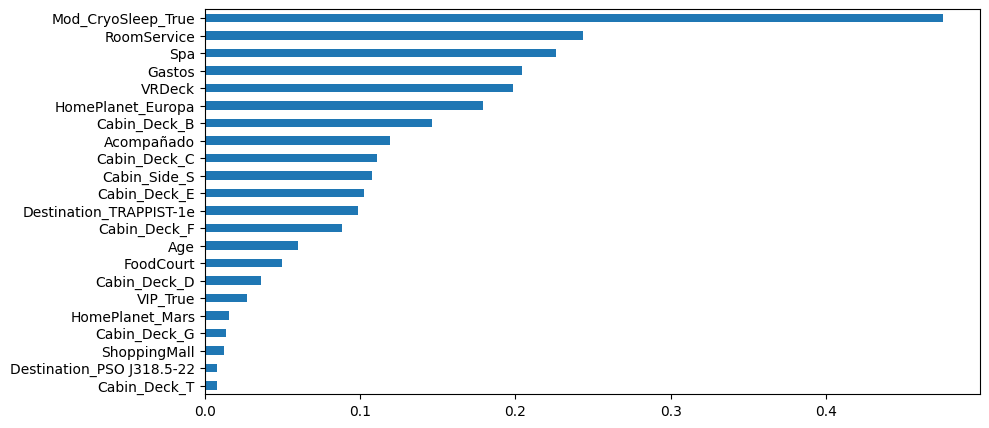

In [40]:
#CORRELACIÓN ENTRE CADA VARIABLE CON EL TARGET

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5),dpi=100)
EDA_train_raw_imputed_scaled_oh.corr().Transported.abs().sort_values(ascending=True).iloc[:-1].plot.barh()
plt.savefig('relaciones.png')
plt.show()


La correlación de Pearson es invariante al escalado
las variabels categóricas ya han sido numerizadas usando one hot y las bool se convierten automáticamente en 1/0
EL FORMATO DE TODO TIENE QUE SER NUMÉRICO

## Introducción a la selección de variables en Machine Learning

### ¿Qué es la selección de variables?

La selección de variables (feature selection) es el proceso mediante el cual se eligen las características más relevantes de un conjunto de datos para construir un modelo de machine learning. Estas características corresponden a las columnas del dataset (por ejemplo, `Age`, `RoomService`, etc.).

Sus principales objetivos son:
- Reducir la complejidad del modelo al trabajar con menos variables.
- Mejorar el rendimiento eliminando ruido o variables irrelevantes.
- Disminuir el coste computacional.

Es importante distinguir este concepto de la **reducción de dimensionalidad**. Mientras que la selección de variables elige un subconjunto de las variables originales, la reducción de dimensionalidad (por ejemplo, mediante PCA) crea nuevas variables a partir de combinaciones de las existentes.

---

### Tipos de métodos de selección de variables

Existen tres grandes categorías: métodos Filter, Wrapper y Embedded.

---

### 1. Métodos Filter (Filtro)

**Definición:**  
Evalúan cada variable de forma independiente utilizando criterios estadísticos, sin necesidad de entrenar un modelo de machine learning.

**Funcionamiento:**  
Se aplican métricas estadísticas para medir la relevancia de cada variable respecto a la variable objetivo. Algunas de las más habituales son:
- Varianza: elimina variables con poca variabilidad.
- Correlación: mide la relación entre variables numéricas.
- Chi-cuadrado: evalúa la relación entre variables categóricas y la variable objetivo.
- ANOVA: analiza la relación entre variables numéricas y una variable objetivo categórica.

**Ejemplos:**
- Eliminar una variable con varianza muy baja (por ejemplo, si casi todos los valores son iguales).
- Detectar variables altamente correlacionadas y considerar eliminar una de ellas (especialmente relevante en modelos lineales por problemas de multicolinealidad).

**Ventajas:**
- Rápidos y computacionalmente eficientes.
- Independientes del modelo utilizado.

**Desventajas:**
- No tienen en cuenta interacciones entre variables.
- Pueden descartar variables que son útiles en combinación con otras.

**Cuándo utilizarlos:**  
Son adecuados como paso inicial para reducir el número de variables antes de aplicar métodos más complejos.

---

### 2. Métodos Wrapper (Envolventes)

**Definición:**  
Utilizan un modelo de machine learning para evaluar distintas combinaciones de variables y seleccionar aquellas que optimizan el rendimiento.

**Funcionamiento:**  
Se entrenan múltiples modelos con distintos subconjuntos de variables y se comparan sus resultados utilizando métricas de evaluación (precisión, error, etc.).

**Ejemplos:**
- Forward Selection: comienza sin variables y añade progresivamente las más relevantes.
- Backward Elimination: comienza con todas las variables y elimina las menos útiles.
- Recursive Feature Elimination (RFE): elimina iterativamente las variables menos importantes según un modelo.

**Ventajas:**
- Tienen en cuenta interacciones entre variables.
- Optimizan directamente el rendimiento del modelo.

**Desventajas:**
- Alto coste computacional.
- Riesgo de sobreajuste si no se utiliza validación cruzada.

**Cuándo utilizarlos:**  
Son útiles cuando se busca maximizar el rendimiento del modelo y se dispone de recursos computacionales suficientes.

---

### 3. Métodos Embedded (Integrados)

**Definición:**  
La selección de variables se realiza de forma automática durante el entrenamiento del modelo.

**Funcionamiento:**  
El propio algoritmo determina la importancia de cada variable como parte de su proceso de aprendizaje.

**Ejemplos:**
- Lasso (regularización L1): reduce a cero los coeficientes de variables irrelevantes, eliminándolas efectivamente del modelo.
- Modelos basados en árboles (Random Forest, Gradient Boosting): proporcionan medidas de importancia de las variables.

**Ventajas:**
- Combinan eficiencia computacional con buen rendimiento.
- Consideran interacciones entre variables.

**Desventajas:**
- Dependen del modelo utilizado.
- Algunas técnicas (como Lasso) pueden no capturar relaciones no lineales.

**Cuándo utilizarlos:**  
Son apropiados cuando ya se ha elegido un modelo concreto y se desea obtener una selección de variables coherente con él.

---

### Comparación entre métodos Filter y Wrapper

- **Filter:** evalúa variables de forma individual mediante estadísticas simples, sin entrenar modelos.
- **Wrapper:** evalúa combinaciones de variables utilizando un modelo de machine learning.

---

### Consideraciones importantes

- La selección de variables debe realizarse únicamente sobre el conjunto de entrenamiento para evitar problemas de *data leakage*.
- No siempre es necesario aplicar selección de variables. Modelos como Random Forest o Gradient Boosting suelen manejar bien un gran número de variables.
- La utilidad de la selección depende del tipo de modelo: es más relevante en modelos lineales o basados en distancias que en modelos basados en árboles.

---

-------------------------------------------------------------------------------------------------------------- 

## Selección de variables: métodos estadísticos y supuestos

La elección del método estadístico depende del tipo de variables (categóricas o numéricas) y de los supuestos que se cumplen.

---

### 1. Variable categórica vs variable categórica

**Test: Chi-cuadrado de independencia**

- Evalúa si existe relación entre dos variables categóricas.
- Supuestos:
  - Observaciones independientes.
  - Frecuencias esperadas suficientemente grandes (habitualmente ≥ 5 por celda).

**Alternativa:**
- Test exacto de Fisher (cuando hay pocas observaciones o frecuencias bajas).

---

### 2. Variable numérica vs variable categórica

**Test: ANOVA (más de dos grupos) o t-test (dos grupos)**

- Evalúa si existen diferencias en la media de la variable numérica entre grupos.

**Supuestos:**
- Normalidad de la variable numérica dentro de cada grupo (ej. test de Shapiro-Wilk).
- Homogeneidad de varianzas (ej. test de Levene o Bartlett).
- Independencia de observaciones.

**Alternativas no paramétricas:**
- Mann-Whitney (dos grupos).
- Kruskal-Wallis (más de dos grupos).

---

### 3. Variable numérica vs variable numérica

**Test: Correlación de Pearson**

- Mide la relación lineal entre dos variables numéricas.

**Supuestos:**
- Relación lineal.
- Normalidad (al menos aproximada).
- Ausencia de outliers significativos.

**Alternativa:**
- Correlación de Spearman (no requiere normalidad, basada en rangos, detecta relaciones monótonas).

---

### 4. Resumen rápido

- Categórica vs categórica → Chi-cuadrado (o Fisher si muestras pequeñas).
- Numérica vs categórica → t-test / ANOVA (o Mann-Whitney / Kruskal-Wallis si no se cumplen supuestos).
- Numérica vs numérica → Pearson (o Spearman si no se cumplen supuestos).

1. Método filter:

1.1 Correlación de Pearson

-   Qué mide: Relación lineal entre dos variables numéricas (valores de -1 a 1).

-   Cuándo usarla: Para variables numéricas (Age, RoomService, FoodCourt, ShoppingMall, Spa, VRDeck, Gastos) y un objetivo numérico. Como Transported es booleano, lo conviertes a 0/1.

    Interpretación:
    -   Cerca de 0: Baja relación → descartar.
    -   Cerca de 1 o -1: Alta relación → mantener.

-   Ejemplo: Correlación entre Spa y Transported. Si es -0.4, Spa influye negativamente (a más gasto en Spa, menos probabilidad de ser transportado).

-   Limitación: Solo captura relaciones lineales.




In [33]:
correlations = EDA_train_raw_imputed.select_dtypes('float64').corrwith(EDA_train_raw_imputed['Transported'].astype(int))
print(correlations)

Age            -0.071536
RoomService    -0.238501
FoodCourt       0.040569
ShoppingMall    0.006267
Spa            -0.213239
VRDeck         -0.202471
Gastos         -0.198520
dtype: float64


Interpretación:

-   La edad tiene una relación débil con Transported. Un aumento en edad reduce ligeramente la probabilidad de ser transportado, pero no es significativo.

-   Más gasto en servicio a la habitación se asocia con menor probabilidad de Transported. Es una variable con cierta relevancia.

-   El gasto en comida no parece influir mucho. Casi no hay relación lineal. 

-   Shopping tiene prácticamente 0. Esta variable no tiene relación lineal con Transported.

-   Más gasto en spa reduce la probabilidad de Transported. Similar a RoomService, tiene relevancia.

-   Más gasto en VR también reduce la probabilidad de Transported. Otra variable con peso.

-   El gasto total (probablemente suma de las anteriores) tiene una relación negativa con Transported. Esto tiene sentido, ya que está influida por RoomService, Spa y VRDeck.

En el método Filter, decides un umbral de correlación para seleccionar variables. Por ejemplo:

Mantener variables con correlación absoluta (|r|) mayor a 0.1 o 0.2 (tú defines el corte según qué tan estricto quieras ser).

Descartar las que estén por debajo (Age, FoodCourt, ShoppingMall)

1.2. Prueba Chi-cuadrado (Chi²)

-   Qué mide: Relación entre variables categóricas y un objetivo categórico.

-   Cuándo usarla: Para variables categóricas (HomePlanet, Destination, VIP, Cabin_Deck, etc.) y Transported.

-   Interpretación:

    -   Valor alto y p-valor < 0.05: Relación significativa → mantener.
    -   Valor bajo o p-valor > 0.05: Sin relación → descartar.

    Ejemplo: Si HomePlanet (Earth, Mars, Europa) tiene un Chi² alto con Transported, es relevante.




In [45]:
EDA_train_raw_imputed.dtypes

HomePlanet        object
Destination       object
Age              float64
VIP               object
RoomService      float64
FoodCourt        float64
ShoppingMall     float64
Spa              float64
VRDeck           float64
Transported         bool
Cabin_Deck        object
Cabin_Num         object
Cabin_Side        object
Gastos           float64
Mod_CryoSleep     object
Acompañado          bool
dtype: object

In [42]:
#CHI2

from sklearn.feature_selection import chi2
import pandas as pd

X = pd.get_dummies(EDA_train_raw_imputed[['HomePlanet', 'Cabin_Deck']])  #usamos las variables categóricas sin one hotear
y = EDA_train_raw_imputed['Transported'].astype(int)
chi_scores, p_values = chi2(X, y)

# Crear el DataFrame
df = pd.DataFrame({'Chi2': chi_scores, 'p-value': p_values}, index=X.columns)

# Formatear la columna p-value a 3 decimales
df['p-value'] = df['p-value'].apply(lambda x: '{:.3f}'.format(x))
print(df)

                         Chi2 p-value
HomePlanet_Earth    75.571912   0.000
HomePlanet_Europa  147.095508   0.000
HomePlanet_Mars      1.201081   0.273
Cabin_Deck_A         0.080022   0.777
Cabin_Deck_B       119.032019   0.000
Cabin_Deck_C        68.223615   0.000
Cabin_Deck_D         7.510260   0.006
Cabin_Deck_E        57.405795   0.000
Cabin_Deck_F        32.492152   0.000
Cabin_Deck_G         0.754475   0.385
Cabin_Deck_T         0.348307   0.555


## Análisis estadístico: p-valor, hipótesis nula y nivel de significancia

### ¿Qué es el p-valor?

El p-valor es una medida estadística que permite evaluar si los resultados observados en los datos son compatibles con la hipótesis nula (H0), o si es poco probable que se deban al azar.

En términos más formales:

> El p-valor representa la probabilidad de observar unos resultados iguales o más extremos que los obtenidos, asumiendo que la hipótesis nula es cierta.

Interpretación práctica:

- p-valor pequeño (por ejemplo, < 0.05): indica que los datos observados son poco probables bajo la hipótesis nula → hay evidencia en contra de H0.
- p-valor grande (por ejemplo, > 0.05): los datos son compatibles con H0 → no hay evidencia suficiente para rechazarla.

---

### ¿Qué es la hipótesis nula (H0)?

La hipótesis nula (H0) es la suposición inicial de que **no existe relación o efecto** entre las variables.

Ejemplo:
- H0: "HomePlanet no influye en Transported"

Es el punto de partida del contraste estadístico. El objetivo del análisis es evaluar si hay suficiente evidencia en los datos para rechazar esta hipótesis.

---

### Nivel de significancia (α) y nivel de confianza

Para tomar decisiones se fija un umbral llamado **nivel de significancia**, denotado como α (alpha).

- Valor típico: α = 0.05

Este valor representa la probabilidad máxima de cometer un **error tipo I**, es decir, rechazar la hipótesis nula cuando en realidad es cierta.

Relación con el nivel de confianza:

- Nivel de confianza = 1 - α
- Si α = 0.05 → nivel de confianza = 95%

---

### Regla de decisión

- Si p-valor < α → se rechaza H0  
- Si p-valor ≥ α → no se rechaza H0  

Importante:
- "No rechazar H0" no significa que sea verdadera, sino que no hay evidencia suficiente en su contra.

---

### Ejemplos

**Para HomePlanet_Europa (p ≈ 0.000):**

- H0: "Venir de Europa no afecta ser transportado"
- El p-valor es extremadamente pequeño → muy improbable bajo H0
- Se rechaza H0 → existe evidencia de que la variable influye en `Transported`

---

**Para Cabin_Deck_A (p = 0.862):**

- H0: "La cubierta A no afecta ser transportado"
- El p-valor es alto → compatible con H0
- No se rechaza H0 → no hay evidencia de efecto

---

### Conclusión (selección de variables)

Basado en el contraste estadístico:

- **Mantener**:  
  HomePlanet_Earth, HomePlanet_Europa, HomePlanet_Mars,  
  Cabin_Deck_B, Cabin_Deck_C, Cabin_Deck_D, Cabin_Deck_E, Cabin_Deck_F  

- **Descartar**:  
  Cabin_Deck_A, Cabin_Deck_G, Cabin_Deck_T  

---

### Nota importante

El p-valor no mide la magnitud del efecto ni la importancia práctica de una variable, sino únicamente la evidencia estadística contra la hipótesis nula. Por tanto, debe complementarse con otras métricas en el contexto de machine learning.

1.3 Ganancia de Información (Mutual Information)

Qué mide: Cuánta información aporta una variable (numérica o categórica) sobre el objetivo, basada en la reducción de entropía.

En castellano: La ganancia de información mide cuánto "sabe" una variable (como Age o HomePlanet) sobre otra (como Transported). Si saber el valor de esa variable reduce la incertidumbre o "desorden" (entropía) sobre Transported, entonces aporta información útil. Hemos dividido los datos por Cabin_Deck (A, B, C, etc.). Si en la cubierta B casi todos son Transported = True y en la A casi todos son False, saber en qué cubierta está alguien te da una pista clara sobre si fue transportado o no. Eso es "alta ganancia de información". Reduce la incertidumbre. Sin saber la cubierta, no tendríamos ni idea; con la cubierta, adivinaremos mejor.

Entropía: Es como medir qué tan "mezclados" o impredecibles son los datos. Si Transported es 50% True y 50% False, hay mucho desorden (alta entropía). Si una variable como Cabin_Deck ayuda a separar esos True y False, la entropía baja y eso es bueno. Menor desorden -> Menor incertidumbre

Cuándo usarla: Para cualquier tipo de variable (numéricas como Age o categóricas como HomePlanet) y un objetivo categórico/binario como Transported.

Puedemos usar esta técnica tanto si las variables son números (como Age o Spa) como si son categorías (como HomePlanet o Cabin_Deck), y funciona bien cuando el objetivo es algo como Transported (True/False, o sea, binario).

Por qué importa: No necesitas preocuparte por el tipo de dato, es súper versátil.

interpretación:

-   0: Sin relación → descartar.
-   Mayor que 0: Aporta información → mantener (valores más altos son mejores).


La ganancia de información mutua (MI) es invariante al escalado de las variables numéricas porque se basa en las distribuciones de probabilidad, no en los valores absolutos.

--------

RESUMEN:  si una variable reduce el "desorden" (o entropía) en la variable objetivo, es útil. Si no cambia nada, no aporta información. Y lo mejor es que esto funciona tanto con variables numéricas como categóricas, y no le afecta si escalas o transformas tus variables, ya que se basa en las probabilidades de los valores, no en los números exactos.

Ganancia de información mutua (ordenada):
Spa           0.075862
Cabin_Deck    0.024123
HomePlanet    0.018641
Age           0.001658
dtype: float64


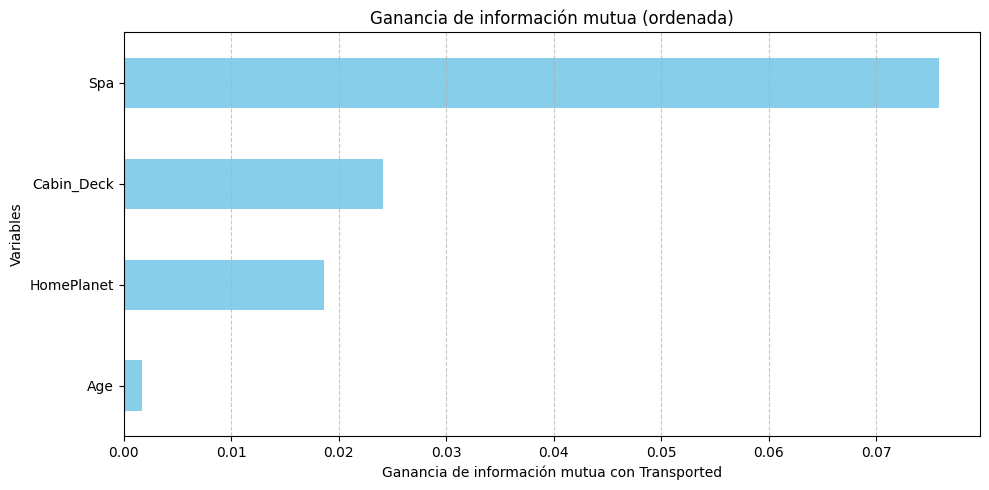

In [44]:
from sklearn.feature_selection import mutual_info_classif
import pandas as pd
import matplotlib.pyplot as plt

# Preparar los datos
# Usar las categóricas originales (sin one-hot) y las numéricas
X = EDA_train_raw_imputed[['HomePlanet', 'Cabin_Deck', 'Age', 'Spa']].copy()

# Codificar las categóricas a valores enteros (label encoding) para que mutual_info_classif las maneje
for col in ['HomePlanet', 'Cabin_Deck']:
    X[col] = X[col].astype('category').cat.codes

# Variable objetivo
y = EDA_train_raw_imputed['Transported'].astype(int)

# Calcular la ganancia de información mutua
# Especificar que HomePlanet y Cabin_Deck son discretas
discrete_features = [True, True, False, False]  # True para categóricas, False para numéricas
mi = mutual_info_classif(X, y, discrete_features=discrete_features, random_state=42)

# Imprimir resultados (ordenados)
print("Ganancia de información mutua (ordenada):")
mi_series = pd.Series(mi, index=X.columns).sort_values(ascending=False)
print(mi_series)

# Visualizar los resultados
plt.figure(figsize=(10, 5), dpi=100)
mi_series.sort_values(ascending=True).plot.barh(color='skyblue')
plt.xlabel('Ganancia de información mutua con Transported')
plt.ylabel('Variables')
plt.title('Ganancia de información mutua (ordenada)')
plt.grid(True, axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Análisis:

## Análisis de la ganancia de información mutua

Se ha calculado la ganancia de información mutua entre varias variables explicativas (`Spa`, `Cabin_Deck`, `HomePlanet`, `Age`) y la variable objetivo (`Transported`), con el fin de evaluar la dependencia entre cada variable y el objetivo.

Los resultados obtenidos son los siguientes:

- Spa: 0.075862  
- Cabin_Deck: 0.024123  
- HomePlanet: 0.018641  
- Age: 0.001658  

---

### Interpretación

La ganancia de información mutua mide la reducción de incertidumbre sobre la variable objetivo al conocer el valor de una variable explicativa. Por tanto, su interpretación debe realizarse de forma relativa, comparando los valores entre variables.

- **Spa** es la variable que mayor información aporta sobre `Transported`, lo que indica una relación más fuerte con la variable objetivo.
- **Cabin_Deck** y **HomePlanet** presentan valores inferiores, lo que sugiere una relación más débil, aunque no despreciable.
- **Age** muestra un valor muy cercano a cero, indicando que, de forma individual, apenas reduce la incertidumbre sobre la variable objetivo.

---

### Consideraciones

Es importante destacar que la ganancia de información mutua es una medida univariante. Esto implica que:

- Evalúa cada variable de forma independiente.
- No tiene en cuenta posibles interacciones entre variables.
- No refleja necesariamente la utilidad de una variable dentro de un modelo multivariante.

Por tanto, una variable con baja ganancia de información puede seguir siendo relevante en combinación con otras variables en modelos más complejos.

---

### Conclusión

La variable `Spa` destaca como la más informativa en relación con `Transported`. `Cabin_Deck` y `HomePlanet` aportan información adicional, aunque en menor medida. Por su parte, `Age` presenta una contribución muy limitada cuando se analiza de forma individual. Estos resultados deben interpretarse como una primera aproximación exploratoria dentro del proceso de selección de variables.


2. MÉTODOS WRAPPER

2.1.RFE

-   RFE significa "Eliminación Recursiva de Características".
-   Es un método Wrapper porque "envuelve" un modelo de machine learning (como regresión logística o un árbol) para decidir qué variables son más importantes.
-   Cómo funciona:
    -   Empieza con todas las variables.
    -   Entrena el modelo y mide la importancia de cada variable.
    -   Elimina la menos importante.
    -   Repite hasta quedarte con el número de variables que quieres.
    -   Por qué es popular: Es automático, usa el modelo para evaluar combinaciones y encuentra las variables que realmente mejoran la predicción.

-   Podemos seleccionar el modelo que queramos, pero debemos tener en cuenta si existe una relación lineal o no entre las variables y la clase. Por ejemplo, si no es lineal no se puede usar logistic regression, dado que solo nos vale para relaciones lineales (aclaración: que tenga una función de activación al final para obtener la p. de una clase, no significa que sea un método válido para un caso donde no hay una relación no lineal entre las variables).

-   Lineal: El efecto de una variable sobre Transported es constante y sigue una línea recta. Ejemplo: a más Spa, la probabilidad de Transported sube/baja siempre igual.
-   No lineal: El efecto cambia según el valor de la variable o combina con otras. Ejemplo: Spa bajo y alto afectan Transported, pero valores medios no.

Podemos usar RandomForest, que maneja tanto relaciones lineales como no lineales, funciona bien con variables numéricas y categóricas. Vaya, un "todoterreno". Es recomendable escalar las numéricas para que RFE sea más equilibrado al comparar numéricas con las categoricas (onehot), sobre todo si hay variaciones grandes.


In [68]:
##RFE

from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
import pandas as pd

# Preparar los datos
# 1. Codificar las categóricas en one-hot
X = pd.get_dummies(EDA_train_raw_imputed[['HomePlanet', 'Cabin_Deck']], drop_first=True)

# 2. Seleccionar las variables numéricas
numeric_cols = ['Age', 'Spa']
X_numeric = EDA_train_raw_imputed[numeric_cols]

# 3. Escalar las variables numéricas
scaler = StandardScaler()
X_numeric_scaled = scaler.fit_transform(X_numeric)
X_numeric_scaled_df = pd.DataFrame(X_numeric_scaled, columns=numeric_cols, index=X.index)

# 4. Combinar las variables one-hot (no escaladas) y las numéricas (escaladas)
X = pd.concat([X, X_numeric_scaled_df], axis=1)

# 5. Preparar la variable objetivo
y = EDA_train_raw_imputed['Transported'].astype(int)

# Crear el modelo Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42)

# Aplicar RFE para seleccionar las 5 mejores variables
rfe = RFE(estimator=model, n_features_to_select=5)
rfe.fit(X, y)

# Resultados
print("Variables seleccionadas:")
print(X.columns[rfe.support_].tolist())
print("\nRanking (1 = seleccionado, >1 = eliminado):")
ranking = pd.Series(rfe.ranking_, index=X.columns)
print(ranking.sort_values())

Variables seleccionadas:
['HomePlanet_Europa', 'HomePlanet_Mars', 'Cabin_Deck_F', 'Age', 'Spa']

Ranking (1 = seleccionado, >1 = eliminado):
HomePlanet_Europa    1
HomePlanet_Mars      1
Cabin_Deck_F         1
Age                  1
Spa                  1
Cabin_Deck_B         2
Cabin_Deck_C         3
Cabin_Deck_E         4
Cabin_Deck_G         5
Cabin_Deck_D         6
Cabin_Deck_T         7
dtype: int64


Reducción de dimensionalidad - PCA (Principal component Analisis)

PCA (Análisis de Componentes Principales) es una técnica de reducción de dimensionalidad. En lugar de seleccionar variables existentes (como hace Feature Selection), PCA crea **nuevas variables (llamadas componentes principales) que son combinaciones lineales de las originales**, maximizando la varianza explicada. Estos componentes son combinaciones lineales de las variables originales y están diseñados para capturar la mayor cantidad posible de varianza en los datos.

Varianza: Es una medida de cuánto se "dispersan" o varían tus datos. Si tienes mucha varianza, tus datos tienen mucha información (cambios, patrones). 
Si tienes poca varianza, tus datos son más uniformes (menos información).
Varianza explicada: Es la cantidad de varianza total de tus datos que un componente (o un grupo de componentes) puede "explicar" o representar.

**Interesa tener el máximo de varianza explicada por las componentes principales**

Cómo funciona (en pasos simples):

-   Estandarizar los datos:
-   Las variables deben estar en la misma escala (ej. restar la media y dividir por la desviación estándar), porque PCA es sensible a las magnitudes.
-   Calcular componentes principales:
    -   PCA encuentra nuevas "direcciones" (componentes) en los datos que explican la mayor cantidad de varianza.
    -   El primer componente (PC1) captura la mayor varianza, el segundo (PC2) la segunda mayor, y así sucesivamente.
    -   Ejemplo: Si tienes Age y Spa, PC1 podría ser algo como 0.7⋅𝐴𝑔𝑒+0.3⋅𝑆𝑝𝑎   -> 1 única componente.

Reducir dimensionalidad:

Eliges cuántos componentes quieres (ej. 2 o 3) para quedarte con los que explican la mayor parte de la varianza (ej. 95%).

Transformar los datos:

-   Tus datos originales (ej. Age, Spa, HomePlanet_Earth, etc.) se convierten en nuevos valores en los componentes (PC1, PC2, etc.). por qué? En lugar de usar las 13 variables originales, podrías usar solo 2 o 3 componentes que expliquen, digamos, el 90% de la varianza.

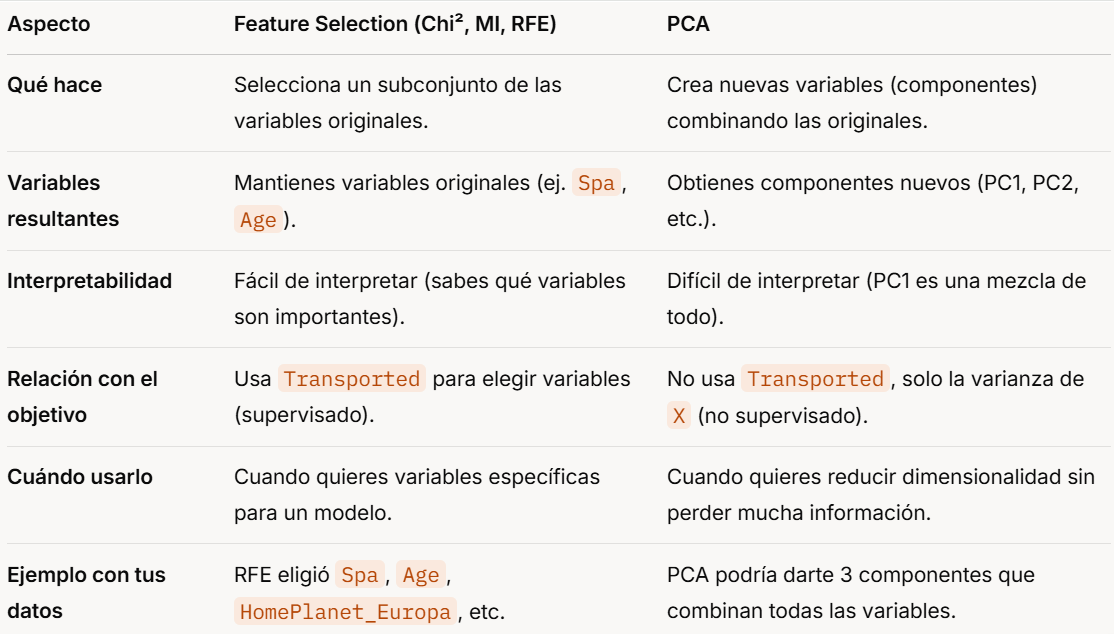

2 approaches distintos, para dejar claro que NO es lo mismo:

-   Feature Selection: "Voy a elegir las mejores variables (ej. Spa, Age) basándome en su relación con Transported".

-   PCA: "Voy a crear nuevas variables (PC1, PC2) que resuman toda la información de mis datos, sin mirar Transported".

En resumen:

Cuando decimos que queremos que los componentes expliquen más del 95% de la varianza, significa que queremos conservar casi toda la información de los datos originales, pero usando menos variables (componentes).

Por qué 95%: 

-   Es un umbral común (puede ser 90%, 99%, etc.) que asegura que no pierdes demasiada información al reducir dimensionalidad.

En PCA:

-   Si los datos originales tienen 13 variables por ejemplo, PCA podría reducirlas a 4 componentes que expliquen el 95% de la varianza.

Esas 4 componentes "resumen" casi toda la información de las 13 variables originales, con la ventaja de ser más eficientes en el entrenamiento.

**En la práctica, al crear nuevas variables como combinación lineal de varias, se pierde un poco el sentido de lo que es cada una y a veees es complicado analizar el resultado**

In [47]:

EDA_train_raw_imputed.dtypes

HomePlanet        object
Destination       object
Age              float64
VIP               object
RoomService      float64
FoodCourt        float64
ShoppingMall     float64
Spa              float64
VRDeck           float64
Transported         bool
Cabin_Deck        object
Cabin_Num         object
Cabin_Side        object
Gastos           float64
Mod_CryoSleep     object
Acompañado          bool
dtype: object

Número de componentes para 95% de varianza: 19


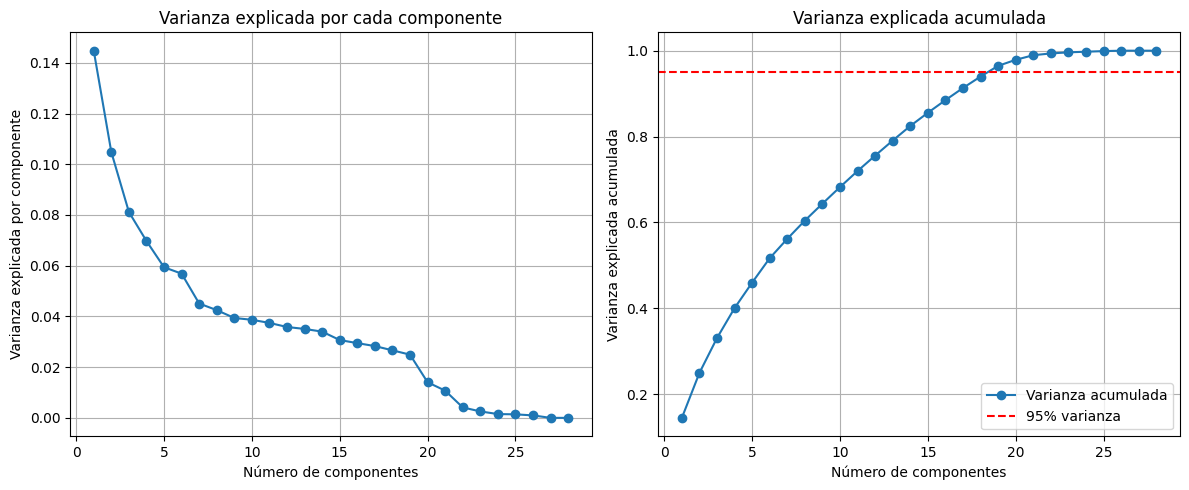


Pesos de las variables en cada componente:
           Age  RoomService  FoodCourt  ShoppingMall       Spa    VRDeck  \
PC1   0.177007     0.096599   0.308286      0.073896  0.252595  0.249716   
PC2  -0.076801    -0.225997   0.027688     -0.172455 -0.016655  0.006136   
PC3   0.011393     0.099204  -0.155770      0.013570 -0.142613 -0.149877   
PC4   0.018782     0.008630   0.021899     -0.013285  0.001881 -0.004549   
PC5  -0.019894    -0.096674   0.074359      0.025092  0.120371  0.059820   
PC6  -0.010392    -0.060217   0.073326     -0.080949  0.040143  0.081694   
PC7  -0.019448     0.331600   0.022702      0.028252  0.087880 -0.038305   
PC8   0.410415    -0.102984  -0.190483     -0.023275 -0.152125 -0.132694   
PC9   0.243065     0.048085  -0.038427      0.137401  0.053044 -0.126295   
PC10  0.419053    -0.029572  -0.028364     -0.292217 -0.038767  0.002194   
PC11 -0.088591     0.180003  -0.085215      0.028961 -0.141552 -0.114500   
PC12 -0.168719     0.045225   0.059185     -

In [48]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 1. Preprocesar los datos
# Separar la variable objetivo
X = EDA_train_raw_imputed.drop(columns=['Transported'])
y = EDA_train_raw_imputed['Transported'].astype(int)

# Convertir booleanas a 0/1
X['Acompañado'] = X['Acompañado'].astype(int)

# Identificar columnas categóricas y numéricas
categorical_cols = ['HomePlanet', 'Destination', 'VIP', 'Cabin_Deck', 'Cabin_Side', 'Mod_CryoSleep']
numeric_cols = ['Age', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Gastos']

# Manejar Cabin_Num (puede tener muchos valores únicos, lo excluimos por ahora)
X = X.drop(columns=['Cabin_Num'])

# Convertir categóricas a dummies (one-hot encoding)
X = pd.get_dummies(X, columns=categorical_cols, drop_first=False)

# 2. Estandarizar los datos
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3. Aplicar PCA
# Usar todos los componentes para analizar la varianza
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Varianza explicada
explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# 4. Elegir número de componentes con el criterio del 95%
n_components_95 = np.argmax(cumulative_variance >= 0.95) + 1
print(f"Número de componentes para 95% de varianza: {n_components_95}")

# 5. Visualizar la varianza explicada (criterio del codo)
plt.figure(figsize=(12, 5))

# Gráfico 1: Varianza explicada por cada componente
plt.subplot(1, 2, 1)
plt.plot(range(1, len(explained_variance) + 1), explained_variance, marker='o', label='Varianza explicada')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza explicada por componente')
plt.title('Varianza explicada por cada componente')
plt.grid(True)

# Gráfico 2: Varianza explicada acumulada
plt.subplot(1, 2, 2)
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', label='Varianza acumulada')
plt.axhline(y=0.95, color='r', linestyle='--', label='95% varianza')
plt.xlabel('Número de componentes')
plt.ylabel('Varianza explicada acumulada')
plt.title('Varianza explicada acumulada')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# 6. Aplicar PCA con el número de componentes elegido (95% varianza)
pca_95 = PCA(n_components=n_components_95)
X_pca_95 = pca_95.fit_transform(X_scaled)

# 7. Mostrar los pesos de las variables en cada componente
components_df = pd.DataFrame(
    pca_95.components_,
    columns=X.columns,
    index=[f'PC{i+1}' for i in range(n_components_95)]
)
print("\nPesos de las variables en cada componente:")
print(components_df)

Análisis:

Qué significan los pesos?

-   Los pesos (o loadings) en cada componente indican cuánto contribuye cada variable original a ese componente.
-   Signo: Un peso positivo significa que la variable contribuye en la misma dirección que el componente; un peso negativo, en dirección opuesta.
-   Magnitud: Cuanto mayor es el valor absoluto del peso, más influye esa variable en el componente.
-   Interpretación: Cada componente es una combinación lineal de las variables originales. Por ejemplo, para PC1:

    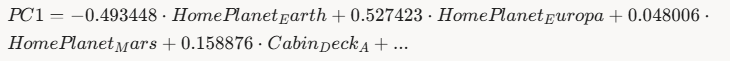


Los 25 componentes corresponden al número de variables efectivas después de preprocesar el DataFrame:
-   Convertir categóricas a dummies.
-   Incluir numéricas y booleanas.
-   Reducir por dependencias lineales.


El criterio del codo busca el punto donde la curva deja de subir rápidamente y se aplana, indicando que añadir más componentes aporta poca ganancia en varianza explicada.

Y con cuántes PC me quedo ahora? Dos criterios:

-   Criterio del codo (10 componentes): Reduces de 25 a 10, pero pierdes ~40% de la varianza.
-   Criterio del 95% (20 componentes): Reduces de 25 a 20, conservando el 95% de la varianza.

PCA podría no ser la mejor opción para este caso de uso. 
